# Forecast TTE v0.1 — Pipeline de Modelado (LightGBM)

**Objetivo:** Construir desde cero el sistema de forecasting de Ausentismo (ABS) y Turnover (TO)
para TTE — Brasil, Shipping. No dependemos de tablas DW de terceros.

**Enfoque:** Antes de modelar, entendemos los datos a fondo.

---

## Roadmap

| Celda | Propósito |
|---|---|
| 1 | Imports y configuración global |
| 2 | Conexión y test BigQuery |
| 3 | Schema de la tabla madre ABS + muestra cruda |
| 4 | Exploración volumétrica: países, job classifications, sitios |
| 5 | Exploración de la tabla madre TO |
| 6 | Nuestra query de agregación ABS (directa desde Silver) |
| 7 | Auditoría de calidad: nulos, imposibles, duplicados, gaps |
| 8 | Análisis de distribuciones por variable |
| 9 | Detección de outliers (IQR + Z-score modificado + visual) |
| 10 | Análisis de series temporales por sitio (heatmap, lifecycles) |

---

> **Tablas fuente (solo lectura):**  
> `meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP`  
> `meli-people.SILVER_PE_SHIPPING.KPI_LATAM_NC_TO_ALL`  
> `meli-people.STG_PE_SHIPPING.ONLY_TTE_REG_CLASSIFICADOR`


---
### Imports y Configuración Global

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path
from google.cloud import bigquery

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ID   = 'meli-people'
PAIS         = 'Brasil'
FECHA_INICIO = '2024-01-01'

TBL_Base_ABS = 'meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP'
TBL_Base_TO  = 'meli-people.SILVER_PE_SHIPPING.KPI_LATAM_NC_TO_ALL'
TBL_REG_Clasiff = 'meli-people.STG_PE_SHIPPING.ONLY_TTE_REG_CLASSIFICADOR'
JOB_Classif = "'Rep de Envio 1', 'Rep de Envio 2'"

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

print('OK Imports')
print(f'   Proyecto : {PROJECT_ID}')
print(f'   Pais     : {PAIS}')
print(f'   Desde    : {FECHA_INICIO}')
print(f'   Cache dir: {DATA_DIR.resolve()}')


OK Imports
   Proyecto : meli-people
   Pais     : Brasil
   Desde    : 2024-01-01
   Cache dir: C:\Users\sergibarra\Documents\SI_People_Analytics_2026\Forecast_TTE\Forecast_TTE_v0\notebooks\data


---
### Conexión y Test BigQuery

En Vertex/Colab ya está autenticado.
En local ejecutar `gcloud auth application-default login` una sola vez.


In [2]:
client = bigquery.Client(project=PROJECT_ID)

# Helper para todas las queries del proyecto.
# create_bqstorage_client=False: usa HTTP en vez de gRPC
# (BigQuery Storage API requiere permisos extra que no tenemos)
def bq_query(sql: str):
    return client.query(sql).to_dataframe(create_bqstorage_client=False)

# Test de conexion
_n = bq_query(f'SELECT COUNT(*) AS n FROM `{TBL_Base_ABS}`').iloc[0, 0]
print(f'OK Conexion BigQuery - {PROJECT_ID}')
print(f'   {TBL_Base_ABS}')
print(f'   Total filas tabla madre ABS: {_n:,}')


OK Conexion BigQuery - meli-people
   meli-people.SILVER_PE_SHIPPING.LK_PE_SHIPPING_ABSENCES_PP
   Total filas tabla madre ABS: 70,578,930


---
### Query de Agregación ABS (versión Jhony)

Query idéntica a la de Jhony Contreras, directo desde Silver.
Filtra Brasil, Rep de Envio 1/2, sitios MELILOG/3PL con match en REG.
Cache local en Parquet: solo golpea BQ cuando hay datos nuevos.

In [5]:
CACHE_ABS = DATA_DIR / 'abs_jhonny.parquet'


def pull_abs_from_bq():
    q = f"""
    SELECT
        EXTRACT(YEAR  FROM AB.YEAR_MONTH_DAY)    AS ANO,
        EXTRACT(MONTH FROM AB.YEAR_MONTH_DAY)    AS MES,
        AB.SITE,
        IFNULL(REG.nome_atual, ' ')              AS Operational_name,
        IFNULL(REG.Site, ' ')                    AS Tipo_OPS,
        AB.ABSENCE_TYPE,
        UPPER(AB.REASON_ABSENCE)                 AS REASON_ABSENCE,
        AB.QUALIFIER_CODE,
        CASE
            WHEN UPPER(AB.REASON_ABSENCE) = 'DOTACION'               THEN 'a.Dotacion'
            WHEN UPPER(AB.REASON_ABSENCE) = 'AUSENCIA INJUSTIFICADA' THEN 'b.Falta_Inj'
            WHEN UPPER(AB.REASON_ABSENCE) = 'ENFERMEDAD'             THEN 'c.Atestados_Medicos'
            ELSE 'd.rest_abs_gestionable'
        END                                      AS TIPO_ABS_GESTIONABLE,
        CASE
            WHEN AB.EXTERNAL_CONTRACTOR = 'No' THEN 'MELI'
            WHEN AB.EXTERNAL_CONTRACTOR = 'Si' THEN 'EXTERNO'
            ELSE ' '
        END                                      AS TIPO_CONTRATO,
        SUM(AB.DOTACION)                         AS Dotacion_programada,
        SUM(AB.ABSENCE_MANAGEABLE)               AS Ausentismo_gestionable
    FROM `{TBL_Base_ABS}` AB
    LEFT JOIN `{TBL_REG_Clasiff}` REG
        ON UPPER(AB.SITE) = UPPER(REG.Ubicacion__Nombre)
    WHERE AB.YEAR_MONTH_DAY BETWEEN DATE '2024-01-01' AND CURRENT_DATE()
        AND AB.COUNTRY = 'Brasil'
        AND AB.ABSENCE_TYPE IN ('Dotacion', 'Gestionable')
        AND REG.logistica IN ('MELILOG', '3PL/MELILOG')
        AND REG.nome_atual NOT LIKE 'FBM%%'
        AND AB.JOB_CLASSIFICATION IN ({JOB_Classif})
    GROUP BY ALL
    """
    print('Ejecutando query ABS en BigQuery...')
    df = bq_query(q)
    df['fecha_mes'] = pd.to_datetime(
        df['ANO'].astype(str) + '-' + df['MES'].astype(str).str.zfill(2) + '-01'
    )
    return df


def cargar_abs(force_refresh=False):
    if not force_refresh and CACHE_ABS.exists():
        df = pd.read_parquet(CACHE_ABS)
        ultimo  = df['fecha_mes'].max()
        mes_ant = pd.Timestamp.now().replace(day=1) - pd.offsets.MonthBegin(1)
        if ultimo >= mes_ant:
            print(f'OK ABS desde cache (ultimo mes: {ultimo.strftime("%Y-%m")})')
            return df
        print(f'Cache desactualizado ({ultimo.strftime("%Y-%m")}). Re-pulling...')
    df = pull_abs_from_bq()
    df.to_parquet(CACHE_ABS)
    print(f'OK ABS guardado en cache: {CACHE_ABS}')
    return df


df_abs_raw = cargar_abs(force_refresh=False)
print(f'Shape  : {df_abs_raw.shape}')
print(f'Rango  : {df_abs_raw["fecha_mes"].min().strftime("%Y-%m")} a {df_abs_raw["fecha_mes"].max().strftime("%Y-%m")}')
print(f'Sitios : {df_abs_raw["Operational_name"].nunique()}')
display(df_abs_raw.head(10))

OK ABS desde cache (ultimo mes: 2026-08)
Shape  : (5758, 13)
Rango  : 2024-01 a 2026-08
Sitios : 89


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable,fecha_mes
0,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"3,023.0000",0.0000,2025-10-01
1,2025,7,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,"10,288.0000",0.0000,2025-07-01
2,2026,1,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Dotacion,DOTACION,P - Presente,a.Dotacion,EXTERNO,611.0000,0.0000,2026-01-01
3,2025,9,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,34.0000,34.0000,2025-09-01
4,2026,2,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000,2026-02-01
5,2026,3,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,4.0000,2026-03-01
6,2026,3,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000,2026-03-01
7,2025,8,SC - SOROCABA SSP20,SC - SOROCABA SSP20,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000,2025-08-01
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,PCO - Protocolo COVID,c.Atestados_Medicos,EXTERNO,1.0000,1.0000,2025-10-01
9,2026,6,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FI - Falta Injustificada,b.Falta_Inj,EXTERNO,83.0000,83.0000,2026-06-01


---
#### Auditoría de Calidad de Datos

**Qué buscamos:**
- Nulos por columna
- Valores imposibles (Dotacion <= 0, ausentismo negativo, ratio > 100%)
- Duplicados en el grano esperado (sitio × mes × tipo)
- Sitios sin match en el clasificador REG
- Gaps temporales por sitio (meses faltantes)

Cada hallazgo se documenta y la decisión de tratamiento se toma **explícitamente**.


In [6]:
# Nulos por columna
def audit_nulos(df):
    nulos = df.isnull().sum()
    pct   = (nulos/len(df)*100).round(2)
    return pd.DataFrame({'nulos':nulos,'pct_%':pct}).query('nulos>0').sort_values('nulos',ascending=False)

dn = audit_nulos(df_abs_raw)
if len(dn):
    print('Columnas con nulos:')
    display(dn)
else:
    print('OK Sin valores nulos')


OK Sin valores nulos


In [7]:
# Valores imposibles
dot_neg = df_abs_raw[
    (df_abs_raw['TIPO_ABS_GESTIONABLE']=='a.Dotacion') & (df_abs_raw['Dotacion_programada']<=0)
]
print(f'Dotacion <= 0 en registros Dotacion: {len(dot_neg):,}')
if len(dot_neg): display(dot_neg.head())

abs_neg = df_abs_raw[df_abs_raw['Ausentismo_gestionable']<0]
print(f'Ausentismo_gestionable < 0: {len(abs_neg):,}')
if len(abs_neg): display(abs_neg.head())

abs_may = df_abs_raw[
    (df_abs_raw['Ausentismo_gestionable']>df_abs_raw['Dotacion_programada']) &
    (df_abs_raw['Dotacion_programada']>0)
]
print(f'Ausentismo > Dotacion (ratio > 100%): {len(abs_may):,}')
if len(abs_may): display(abs_may.head())


Dotacion <= 0 en registros Dotacion: 0
Ausentismo_gestionable < 0: 0
Ausentismo > Dotacion (ratio > 100%): 0


In [8]:
# Duplicados en el grano esperado
grano = ['Operational_name','fecha_mes','TIPO_CONTRATO','TIPO_ABS_GESTIONABLE']
dupes = df_abs_raw[df_abs_raw.duplicated(subset=grano,keep=False)]
print(f'Duplicados en el grano: {len(dupes):,}')
if len(dupes): display(dupes.head(20))
else: print('OK Sin duplicados')

Duplicados en el grano: 1,102


,ANO,MES,SITE,Operational_name,Tipo_OPS,ABSENCE_TYPE,REASON_ABSENCE,QUALIFIER_CODE,TIPO_ABS_GESTIONABLE,TIPO_CONTRATO,Dotacion_programada,Ausentismo_gestionable,fecha_mes
4,2026,2,SC - MEGA BARUERI SSP5,SC - MEGA BARUERI SSP5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,2.0000,2026-02-01
5,2026,3,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,4.0000,2026-03-01
8,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,PCO - Protocolo COVID,c.Atestados_Medicos,EXTERNO,1.0000,1.0000,2025-10-01
12,2026,4,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,PERMISOS LÍDER,FJ - Abono Gestor,d.rest_abs_gestionable,EXTERNO,5.0000,5.0000,2026-04-01
17,2026,4,SC - CONTAGEM II SGM15,SC - CONTAGEM II SMG15,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,3.0000,2026-04-01
18,2026,4,RC - Sumaré RC02,RC - SUMARE RC02,TTE,Gestionable,AUSENCIA INJUSTIFICADA,FJ - Abono Fretado (falta),b.Falta_Inj,EXTERNO,3.0000,3.0000,2026-04-01
22,2026,6,SC - GOIÂNIA SG01,SC - GOIANIA SGO1,TTE,Gestionable,PERMISOS LÍDER,Licença Excepcional Com Remuneração,d.rest_abs_gestionable,MELI,0.0000,3.0000,2026-06-01
23,2025,8,SC - PASSO FUNDO SRS5,SC - PASSO FUNDO SRS5,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,1.0000,2025-08-01
27,2025,10,RC - SUMARÉ RC02,RC - SUMARE RC02,TTE,Gestionable,ENFERMEDAD,FJ - Atestado,c.Atestados_Medicos,EXTERNO,143.0000,143.0000,2025-10-01
31,2026,4,SOC - CAJAMAR SOC1,SORTATION CENTER - CAJAMAR SOC1,TTE,Gestionable,PERMISO SERVICIO MÉDICO,Acompanhamento,d.rest_abs_gestionable,MELI,0.0000,18.0000,2026-04-01


In [9]:
# Gaps temporales por sitio
df_dot = df_abs_raw[
    df_abs_raw['TIPO_ABS_GESTIONABLE']=='a.Dotacion'
].groupby(['Operational_name','fecha_mes'])['Dotacion_programada'].sum().reset_index()

all_m  = pd.date_range(df_dot['fecha_mes'].min(), df_dot['fecha_mes'].max(), freq='MS')
idx    = pd.MultiIndex.from_product([df_dot['Operational_name'].unique(), all_m],
                                     names=['Operational_name','fecha_mes'])
df_gap = pd.DataFrame(index=idx).reset_index().merge(df_dot, on=['Operational_name','fecha_mes'], how='left')
df_gap['ok'] = df_gap['Dotacion_programada'].notna()

df_gs = df_gap.groupby('Operational_name').agg(
    meses_tot = ('fecha_mes','count'),
    meses_ok  = ('ok','sum'),
    pct_cob   = ('ok', lambda x: round(x.mean()*100,1))
).reset_index()
df_gs['meses_faltantes'] = df_gs['meses_tot'] - df_gs['meses_ok']
df_gs = df_gs.sort_values('pct_cob')

print(f'Total sitios: {len(df_gs)}')
print(f'  Cobertura 100%   : {(df_gs["pct_cob"]==100).sum()}')
print(f'  Con meses faltantes: {(df_gs["pct_cob"]<100).sum()}')
print(f'  Con <50% cobertura : {(df_gs["pct_cob"]<50).sum()} (candidatos a excluir)')
display(df_gs.head(20))


Total sitios: 89
  Cobertura 100%   : 27
  Con meses faltantes: 62
  Con <50% cobertura : 42 (candidatos a excluir)


,Operational_name,meses_tot,meses_ok,pct_cob,meses_faltantes
15,SC - FRANCA SSP26,32,1,3.1000,31
51,SC - SIMOES FILHO SBA1,32,1,3.1000,31
72,XD - GUARULHOS MEGA BRXSP10,32,1,3.1000,31
64,XD - CAMPINA GRANDE SUL BRXPR1,32,1,3.1000,31
81,XD - RIBEIRAO PRETO BRXSP5,32,1,3.1000,31
16,SC - FRANCO DA ROCHA SSP32,32,2,6.2000,30
45,SC - PRESIDENTE PRUDENTE SSP11,32,3,9.4000,29
27,SC - JOINVILLE SSC1,32,3,9.4000,29
77,XD - MEGA CRAVINHOS BRXSP15,32,3,9.4000,29
13,SC - CRAVINHOS SSP4,32,3,9.4000,29


---
###Análisis de Distribuciones

Pivoteamos a nivel sitio × mes y analizamos las distribuciones de las métricas objetivo:
`ABS_Total`, `ABS_Falta`, `ABS_Atestados`, `ABS_Rest`, `Dotacion`.

Entender la distribución es clave para elegir el modelo correcto y el tratamiento de outliers.


In [10]:
# FIX 2026-08-14: SITE y Tipo_OPS eliminados del index del pivot.
# El pivot original incluia SITE y Tipo_OPS en el index, generando una fila
# por cada combinacion (ej: MELI y EXTERNO por separado para el mismo sitio+mes).
# Esto causaba pares duplicados (Operational_name, fecha_mes) que producian
# zigzags en los graficos y errores en el calculo de MAPE/MAE.
# El fix agrega directamente al nivel (Operational_name, fecha_mes) sumando
# conteos brutos antes de calcular las tasas — matematicamente correcto.

# Pivot al nivel (sitio x mes), MELI+EXTERNO realmente combinados
df_pb = df_abs_raw.groupby(
    ['Operational_name', 'fecha_mes', 'TIPO_ABS_GESTIONABLE']
).agg(dot=('Dotacion_programada', 'sum'), ab=('Ausentismo_gestionable', 'sum')).reset_index()

df_pb['v'] = np.where(df_pb['TIPO_ABS_GESTIONABLE'] == 'a.Dotacion', df_pb['dot'], df_pb['ab'])

df_pivot = df_pb.pivot_table(
    index=['Operational_name', 'fecha_mes'],
    columns='TIPO_ABS_GESTIONABLE', values='v', aggfunc='sum'
).reset_index()
df_pivot.columns.name = None
df_pivot = df_pivot.rename(columns={
    'a.Dotacion': 'Dotacion', 'b.Falta_Inj': 'Falta_Inj',
    'c.Atestados_Medicos': 'Atestados_Medicos', 'd.rest_abs_gestionable': 'Rest_Abs_Gestionable'
})
for c in ['Dotacion', 'Falta_Inj', 'Atestados_Medicos', 'Rest_Abs_Gestionable']:
    if c not in df_pivot.columns:
        df_pivot[c] = 0.0
    df_pivot[c] = df_pivot[c].fillna(0)

df_pivot['Ausencia_Total'] = df_pivot['Falta_Inj'] + df_pivot['Atestados_Medicos'] + df_pivot['Rest_Abs_Gestionable']
m = df_pivot['Dotacion'] > 0
df_pivot['ABS_Total']    = np.where(m, df_pivot['Ausencia_Total'] / df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Falta']    = np.where(m, df_pivot['Falta_Inj']       / df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Atestado'] = np.where(m, df_pivot['Atestados_Medicos'] / df_pivot['Dotacion'], np.nan)
df_pivot['ABS_Rest']     = np.where(m, df_pivot['Rest_Abs_Gestionable'] / df_pivot['Dotacion'], np.nan)

# Verificar que no queden duplicados
dups = df_pivot.groupby(['Operational_name', 'fecha_mes']).size()
n_dups = (dups > 1).sum()
print(f'df_pivot: {df_pivot.shape}')
print(f'Sitios: {df_pivot["Operational_name"].nunique()} | Meses: {df_pivot["fecha_mes"].nunique()}')
print(f'Pares (sitio, mes) duplicados: {n_dups}  <- debe ser 0')
if n_dups > 0:
    print(dups[dups > 1].head(10))
display(df_pivot.describe())


df_pivot: (1545, 11)
Sitios: 89 | Meses: 32
Pares (sitio, mes) duplicados: 0  <- debe ser 0


,fecha_mes,Dotacion,Falta_Inj,Atestados_Medicos,Rest_Abs_Gestionable,Ausencia_Total,ABS_Total,ABS_Falta,ABS_Atestado,ABS_Rest
count,1545,"1,545.0000","1,545.0000","1,545.0000","1,545.0000","1,545.0000","1,545.0000","1,545.0000","1,545.0000","1,545.0000"
mean,2025-06-27 15:51:36.699029,"3,141.5974",169.2828,124.6718,12.6641,306.6188,0.0708,0.0344,0.0331,0.0033
min,2024-01-01 00:00:00,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2024-12-01 00:00:00,677.0000,1.0000,13.0000,0.0000,26.0000,0.0322,0.0010,0.0178,0.0000
50%,2025-08-01 00:00:00,"1,427.0000",19.0000,44.0000,1.0000,74.0000,0.0581,0.0159,0.0309,0.0007
75%,2026-03-01 00:00:00,"2,589.0000",113.0000,94.0000,6.0000,219.0000,0.0943,0.0481,0.0455,0.0031
max,2026-08-01 00:00:00,"75,264.0000","8,231.0000","5,213.0000",858.0000,"12,526.0000",0.8000,0.8000,0.2857,0.3934
std,NaN,"6,859.7627",528.6132,357.0829,52.5751,895.6997,0.0592,0.0516,0.0234,0.0141


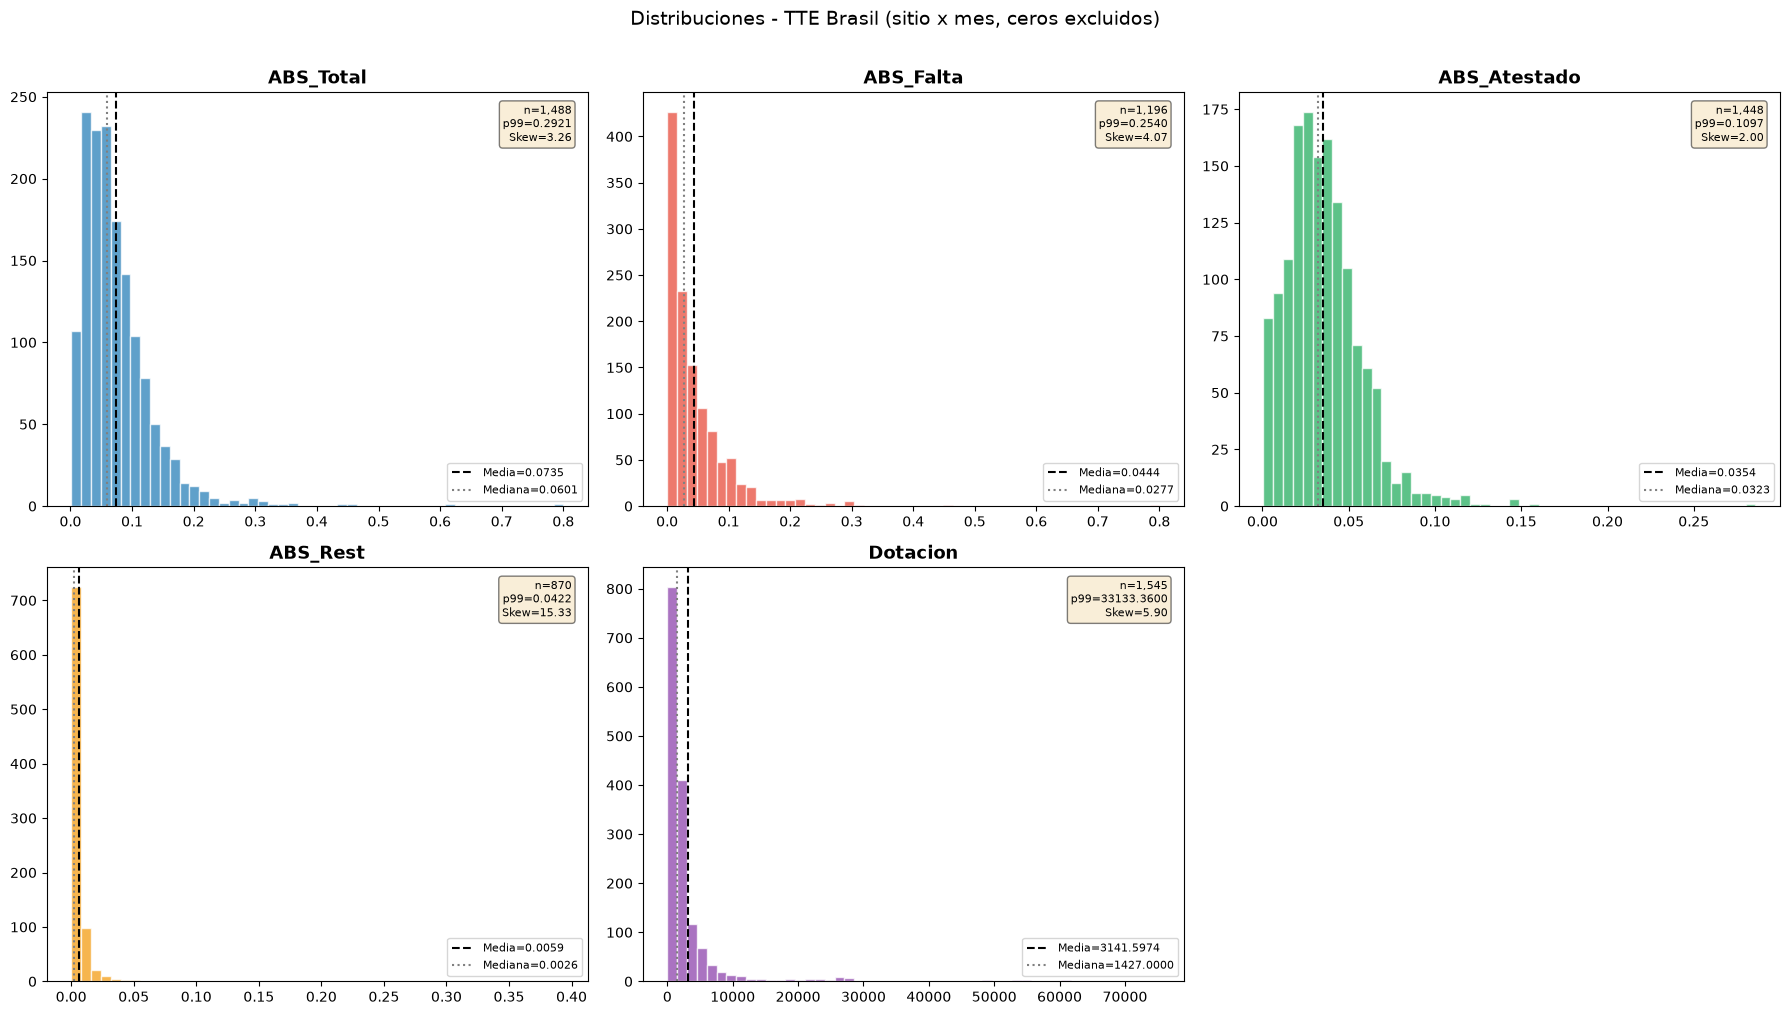


Estadisticas:


,n,Media,Mediana,Std,p5,p25,p75,p95,p99,Skewness,Kurtosis
Metrica,,,,,,,,,,,
ABS_Total,1488,0.0735,0.0601,0.0586,0.0134,0.0348,0.0961,0.1709,0.2921,3.2622,24.3324
ABS_Falta,1196,0.0444,0.0277,0.0548,0.0015,0.0092,0.0599,0.1349,0.2540,4.0702,35.9537
ABS_Atestado,1448,0.0354,0.0323,0.0225,0.0055,0.0202,0.0467,0.0720,0.1097,1.9964,12.7243
ABS_Rest,870,0.0059,0.0026,0.0184,0.0005,0.0013,0.0057,0.0166,0.0422,15.3256,280.7268
Dotacion,1545,"3,141.5974","1,427.0000","6,859.7627",119.0000,677.0000,"2,589.0000","10,397.8000","33,133.3600",5.9033,42.2763


In [11]:
mets    = ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest','Dotacion']
cols    = ['#2980b9','#e74c3c','#27ae60','#f39c12','#8e44ad']
fig, ax = plt.subplots(2, 3, figsize=(18,10))
ax      = ax.flatten()
rows    = []

for i,(met,color) in enumerate(zip(mets,cols)):
    d = df_pivot[met].dropna()
    d = d[d>0]
    ax[i].hist(d, bins=50, color=color, alpha=0.75, edgecolor='white')
    ax[i].axvline(d.mean(),   color='black', ls='--', lw=1.5, label=f'Media={d.mean():.4f}')
    ax[i].axvline(d.median(), color='gray',  ls=':',  lw=1.5, label=f'Mediana={d.median():.4f}')
    ax[i].set_title(met, fontsize=13, fontweight='bold')
    ax[i].legend(fontsize=8)
    ax[i].text(0.97,0.97,f'n={len(d):,}\np99={d.quantile(.99):.4f}\nSkew={d.skew():.2f}',
               transform=ax[i].transAxes, ha='right', va='top', fontsize=8,
               bbox=dict(boxstyle='round',facecolor='wheat',alpha=0.5))
    rows.append({'Metrica':met,'n':len(d),'Media':d.mean(),'Mediana':d.median(),
                 'Std':d.std(),'p5':d.quantile(.05),'p25':d.quantile(.25),
                 'p75':d.quantile(.75),'p95':d.quantile(.95),'p99':d.quantile(.99),
                 'Skewness':d.skew(),'Kurtosis':d.kurtosis()})

ax[-1].set_visible(False)
plt.suptitle('Distribuciones - TTE Brasil (sitio x mes, ceros excluidos)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print('\nEstadisticas:')
display(pd.DataFrame(rows).set_index('Metrica').round(4))


---
#### — Detección y Tratamiento de Outliers

**Tres enfoques complementarios:**
1. **IQR (Tukey)** — robusto ante distribuciones asimétricas
2. **Z-score modificado (MAD)** — más robusto que el Z clásico ante heavy tails
3. **Boxplot interactivo** — para distinguir errores de picos estacionales reales

> En series de tiempo, un outlier puede ser real (brote de gripe, huelga, evento climático).  
> La decisión de winsorizar, marcar o eliminar se hace **explícitamente**, no de forma ciega.


In [12]:
def out_iqr(s, f=1.5):
    Q1,Q3 = s.quantile([.25,.75])
    return (s<Q1-f*(Q3-Q1)) | (s>Q3+f*(Q3-Q1))


def out_zmod(s, u=3.5):
    med = s.median()
    mad = (s-med).abs().median()
    if mad==0: return pd.Series(False, index=s.index)
    return (0.6745*(s-med)/mad).abs() > u


df_out = df_pivot[df_pivot['Dotacion']>0].copy()
for met in ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']:
    s = df_out[met].fillna(0)
    df_out[f'{met}_oi'] = out_iqr(s)
    df_out[f'{met}_oz'] = out_zmod(s)
    df_out[f'{met}_ob'] = df_out[f'{met}_oi'] & df_out[f'{met}_oz']

rows = []
for met in ['ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']:
    rows.append({'Metrica':met,
                 'IQR':df_out[f'{met}_oi'].sum(),
                 'Z-mod':df_out[f'{met}_oz'].sum(),
                 'Ambos (alta confianza)':df_out[f'{met}_ob'].sum()})
print('Resumen outliers (solo registros con Dotacion > 0):')
display(pd.DataFrame(rows).set_index('Metrica'))


Resumen outliers (solo registros con Dotacion > 0):


,IQR,Z-mod,Ambos (alta confianza)
Metrica,,,
ABS_Total,55,38,38
ABS_Falta,91,141,91
ABS_Atestado,35,19,19
ABS_Rest,153,286,153


In [13]:
# Boxplot interactivo Top 30 sitios por mediana ABS_Total
top30 = df_out.groupby('Operational_name')['ABS_Total'].median().sort_values(ascending=False).head(30).index.tolist()
fig = px.box(
    df_out[df_out['Operational_name'].isin(top30)],
    x='Operational_name', y='ABS_Total',
    category_orders={'Operational_name':top30},
    title='ABS_Total por Sitio - Top 30 por mediana (outliers como puntos)',
    color='Operational_name', points='outliers'
)
fig.update_layout(height=550, showlegend=False, xaxis_tickangle=-60, xaxis_title='')
fig.show()


In [14]:
# Tabla de outliers de alta confianza para revisión manual
cols_s = ['Operational_name','fecha_mes','Dotacion',
           'Falta_Inj','Atestados_Medicos','Rest_Abs_Gestionable',
           'ABS_Total','ABS_Falta','ABS_Atestado','ABS_Rest']
df_ohc = df_out[df_out['ABS_Total_ob']][[c for c in cols_s if c in df_out]].sort_values('ABS_Total',ascending=False)
print(f'Outliers alta confianza: {len(df_ohc):,} registros en {df_ohc["Operational_name"].nunique()} sitios')
print('Revisar caso por caso antes de decidir tratamiento.')
display(df_ohc.head(20))


Outliers alta confianza: 38 registros en 26 sitios
Revisar caso por caso antes de decidir tratamiento.


,Operational_name,fecha_mes,Dotacion,Falta_Inj,Atestados_Medicos,Rest_Abs_Gestionable,ABS_Total,ABS_Falta,ABS_Atestado,ABS_Rest
1532,XD - ZONA NORTE XSP16,2025-08-01,5.0000,4.0000,0.0000,0.0000,0.8000,0.8000,0.0000,0.0000
843,SC - SAO BERNARDO DO CAMPO SSP17,2026-04-01,"1,187.0000",255.0000,5.0000,467.0000,0.6125,0.2148,0.0042,0.3934
36,SC - ARACATUBA SSP10,2026-03-01,48.0000,22.0000,0.0000,0.0000,0.4583,0.4583,0.0000,0.0000
10,AH - GUARULHOS SSP19,2026-06-01,69.0000,20.0000,10.0000,0.0000,0.4348,0.2899,0.1449,0.0000
9,AH - GUARULHOS SSP19,2026-05-01,89.0000,19.0000,13.0000,0.0000,0.3596,0.2135,0.1461,0.0000
8,AH - GUARULHOS SSP19,2026-04-01,96.0000,20.0000,14.0000,0.0000,0.3542,0.2083,0.1458,0.0000
453,SC - JUNDIAI SSP18,2026-07-01,"11,872.0000","3,570.0000",468.0000,2.0000,0.3403,0.3007,0.0394,0.0002
116,SC - CASCAVEL SPR3,2026-07-01,"4,474.0000","1,422.0000",54.0000,2.0000,0.3304,0.3178,0.0121,0.0004
232,SC - CRAVINHOS SSP4,2026-07-01,"4,382.0000","1,332.0000",51.0000,9.0000,0.3177,0.3040,0.0116,0.0021
452,SC - JUNDIAI SSP18,2026-06-01,"12,510.0000","3,642.0000",218.0000,76.0000,0.3146,0.2911,0.0174,0.0061


---
###  Análisis de Series Temporales por Sitio

**Estructura temporal antes de modelar:**
- ¿Los sitios muestran tendencia, estacionalidad o solo ruido?
- ¿Hay sitios con distintas fechas de inicio/fin (lifecycles)?
- ¿Cuántos meses reales tiene cada sitio?

Esto define el mínimo de historia requerido y la estrategia de feature engineering.


In [15]:
df_hist = df_pivot[df_pivot['Dotacion']>0].groupby('Operational_name').agg(
    fecha_inicio = ('fecha_mes','min'),
    fecha_fin    = ('fecha_mes','max'),
    n_meses      = ('fecha_mes','count'),
    dot_media    = ('Dotacion','mean'),
    abs_media    = ('ABS_Total','mean'),
    abs_std      = ('ABS_Total','std')
).reset_index()
df_hist['cv_abs'] = (df_hist['abs_std']/df_hist['abs_media']).round(3)
df_hist = df_hist.sort_values('n_meses',ascending=False)

print('Historia por sitio:')
print(f'  >= 18 meses: {(df_hist["n_meses"]>=18).sum()}')
print(f'  >= 12 meses: {(df_hist["n_meses"]>=12).sum()}')
print(f'  >=  6 meses: {(df_hist["n_meses"]>=6).sum()}')
print(f'   <  6 meses: {(df_hist["n_meses"]<6).sum()} (candidatos a excluir)')
display(df_hist.head(20))


Historia por sitio:
  >= 18 meses: 43
  >= 12 meses: 54
  >=  6 meses: 70
   <  6 meses: 19 (candidatos a excluir)


,Operational_name,fecha_inicio,fecha_fin,n_meses,dot_media,abs_media,abs_std,cv_abs
8,SC - CAXIAS DO SUL SRS4,2024-01-01,2026-08-01,32,"1,134.1875",0.0644,0.0428,0.6640
17,SC - GASPAR SSC3,2024-01-01,2026-08-01,32,"1,107.1875",0.0697,0.0471,0.6750
22,SC - IPATINGA SMG4,2024-01-01,2026-08-01,32,485.3750,0.0456,0.0365,0.7990
11,SC - CONTAGEM SMG1,2024-01-01,2026-08-01,32,"2,039.5625",0.0900,0.0355,0.3950
67,XD - CONTAGEM BRXMG1,2024-01-01,2026-08-01,32,"3,231.5312",0.0690,0.0269,0.3900
76,XD - MEGA BARUERI BRXSP1,2024-01-01,2026-08-01,32,"13,308.6250",0.0712,0.0233,0.3270
73,XD - LONDRINA BRXPR2,2024-01-01,2026-08-01,32,775.8750,0.0526,0.0256,0.4860
61,SC - ZONA SUL SSP1,2024-01-01,2026-08-01,32,"2,144.2188",0.0569,0.0305,0.5360
56,SC - UBERLANDIA SMG6,2024-01-01,2026-08-01,32,"1,126.0000",0.0861,0.0550,0.6390
41,SC - PASSO FUNDO SRS5,2024-01-01,2026-08-01,32,"1,115.7812",0.0475,0.0351,0.7390


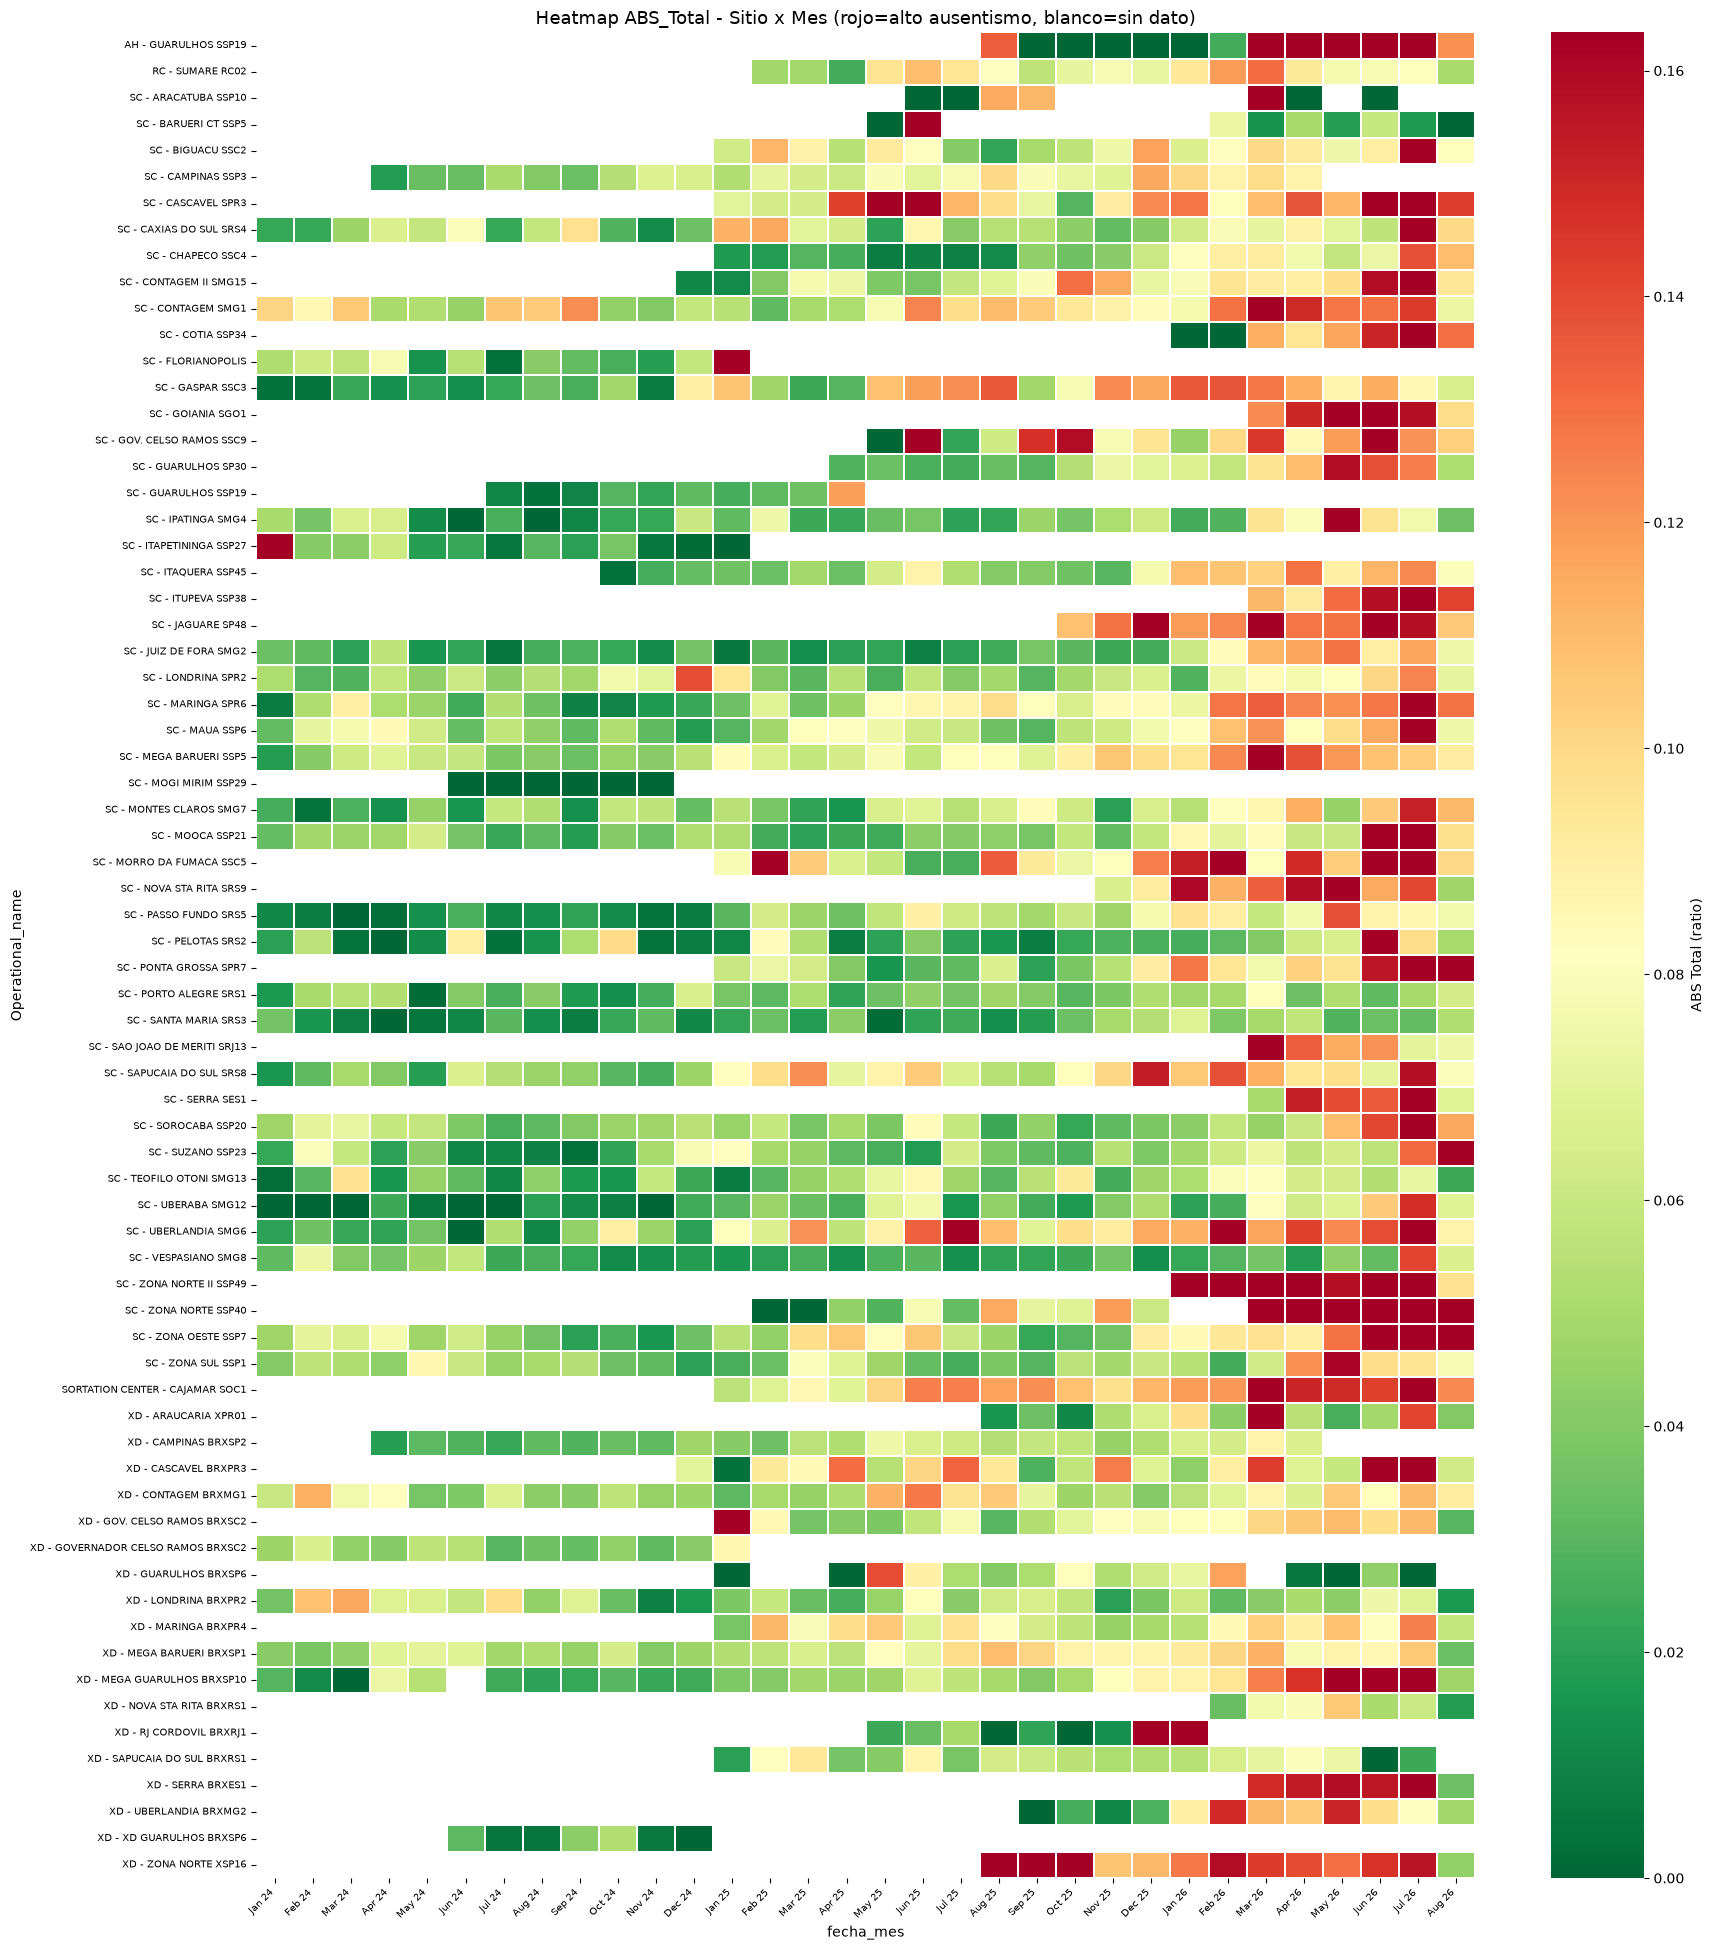

Meses: 32 | Sitios: 70


In [16]:
# Heatmap: ABS_Total por Sitio x Mes
sitios_ok = df_hist[df_hist['n_meses']>=6]['Operational_name'].tolist()
df_hm = df_pivot[
    df_pivot['Operational_name'].isin(sitios_ok) & (df_pivot['Dotacion']>0)
].pivot_table(index='Operational_name', columns='fecha_mes', values='ABS_Total')

fig, ax = plt.subplots(figsize=(18, max(8, len(sitios_ok)*0.28)))
sns.heatmap(df_hm, ax=ax, cmap='RdYlGn_r', annot=False, linewidths=0.3,
            vmin=0, vmax=df_hm.stack().quantile(0.95),
            cbar_kws={'label':'ABS Total (ratio)'})
ax.set_title('Heatmap ABS_Total - Sitio x Mes (rojo=alto ausentismo, blanco=sin dato)', fontsize=13)
ax.set_xticklabels(
    [pd.Timestamp(t.get_text()).strftime('%b %y') for t in ax.get_xticklabels()],
    rotation=45, ha='right', fontsize=7
)
ax.tick_params(axis='y', labelsize=7)
plt.tight_layout()
plt.show()
print(f'Meses: {df_hm.shape[1]} | Sitios: {df_hm.shape[0]}')


In [17]:
# Series temporales Top 6 sitios por dotacion media
top6 = df_pivot[df_pivot['Dotacion']>0].groupby('Operational_name')['Dotacion'].mean().nlargest(6).index.tolist()
fig  = make_subplots(rows=3, cols=2, subplot_titles=top6, vertical_spacing=0.12)
for i,site in enumerate(top6):
    r,c = divmod(i,2)
    ds  = df_pivot[df_pivot['Operational_name']==site].sort_values('fecha_mes')
    fig.add_trace(
        go.Scatter(x=ds['fecha_mes'], y=(ds['ABS_Total']*100).round(2),
                   mode='lines+markers', name='ABS%',
                   line=dict(color='#e74c3c',width=2), marker=dict(size=5)),
        row=r+1, col=c+1
    )
fig.update_layout(height=800, showlegend=False, template='plotly_white',
                  title_text='Series ABS_Total - Top 6 sitios por Dotacion media')
fig.update_yaxes(title_text='ABS %')
fig.show()


---
## Hallazgos de esta fase (completar al ejecutar)

| # | Hallazgo | Decisión |
|---|---|---|
| 1 | | |
| 2 | | |
| 3 | | |

---

## Próximos notebooks

| Notebook | Qué haremos |
|---|---|
| **v1 — Limpieza** | Tratamiento de outliers, gaps, sitios a excluir |
| **v2 — Feature Engineering** | Lags, rolling, estacionalidad, covariables externas |
| **v3 — Modelado ABS** | Benchmark: Naive, SARIMA, CatBoost/LGBM, modelos fundacionales |
| **v4 — Modelado TO** | Mismo proceso para Turnover |
| **v5 — Validación** | Walk-forward riguroso, métricas por sitio |
| **v6 — Producción** | Pipeline completo, schedule mensual |


---
### Modelado: Naive Estacional (Baseline)

**El modelo mas simple posible: para cada sitio, la prediccion de cada mes es
el promedio historico de ese mismo mes en los anios anteriores.**

Ejemplo: prediccion Feb 2026 = avg(Feb 2024, Feb 2025) por sitio.

| Parametro | Valor |
|---|---|
| Train | ene 2024 → ene 2026 |
| Validacion | feb 2026 → jul 2026 (6 meses, horizonte real) |
| Sitios elegibles | >= 6 meses de train con Dotacion > 0 |
| Metrica | MAPE sobre ABS_Total (ratio ausentismo/dotacion) |

Si un modelo complejo no supera este baseline, el modelo complejo esta mal.
Referencia Jhony CatBoost walk-forward: ~38.56%

In [18]:
# Setup: cutoff, split y sitios elegibles
CUTOFF    = pd.Timestamp('2026-01-31')
VAL_START = pd.Timestamp('2026-02-01')
VAL_END   = pd.Timestamp('2026-07-31')
MIN_MESES_TRAIN = 6

df_work = df_pivot[df_pivot['Dotacion'] > 0].copy()
df_tr   = df_work[df_work['fecha_mes'] <= CUTOFF].copy()
df_va   = df_work[(df_work['fecha_mes'] >= VAL_START) & (df_work['fecha_mes'] <= VAL_END)].copy()

sitios_ok = (
    df_tr.groupby('Operational_name')['fecha_mes'].count()
    .loc[lambda s: s >= MIN_MESES_TRAIN].index
)

# Filtro de recencia: el sitio debe tener datos en los ultimos 3 meses de train.
# Excluye sitios que dejaron de reportar antes del CUTOFF (sin forecast util).
RECENCIA_MESES = 3
fecha_recencia = (CUTOFF - pd.DateOffset(months=RECENCIA_MESES - 1)).replace(day=1)
sitios_recientes = set(
    df_tr[df_tr['fecha_mes'] >= fecha_recencia]['Operational_name'].unique()
)
sitios_ok = sitios_ok[sitios_ok.isin(sitios_recientes)]

df_tr = df_tr[df_tr['Operational_name'].isin(sitios_ok)].copy()
df_va = df_va[df_va['Operational_name'].isin(sitios_ok)].copy()

print(f'Cutoff     : train <= {CUTOFF.strftime("%Y-%m")},  val {VAL_START.strftime("%Y-%m")} -> {VAL_END.strftime("%Y-%m")}')
print(f'Sitios OK  : {len(sitios_ok)} (de {df_pivot["Operational_name"].nunique()} totales)')
print(f'Filas train: {len(df_tr):,}  |  Filas val: {len(df_va):,}')

meses_por_sitio = df_tr.groupby('Operational_name')['fecha_mes'].count()
print(f'\nMeses en train por sitio:')
print(f'  >= 18 meses: {(meses_por_sitio >= 18).sum()}')
print(f'  12-17 meses: {((meses_por_sitio >= 12) & (meses_por_sitio < 18)).sum()}')
print(f'   6-11 meses: {((meses_por_sitio >= 6)  & (meses_por_sitio < 12)).sum()}')

Cutoff     : train <= 2026-01,  val 2026-02 -> 2026-07
Sitios OK  : 51 (de 89 totales)
Filas train: 984  |  Filas val: 292

Meses en train por sitio:
  >= 18 meses: 30
  12-17 meses: 13
   6-11 meses: 8


In [19]:
# Naive Estacional: pred = avg historico por sitio x mes_del_anio
df_tr['mes'] = df_tr['fecha_mes'].dt.month
naive_map = (
    df_tr.groupby(['Operational_name', 'mes'])['ABS_Total']
    .mean().reset_index().rename(columns={'ABS_Total': 'pred'})
)

# Fallback: media global del sitio (para meses nunca vistos en train)
media_sitio = df_tr.groupby('Operational_name')['ABS_Total'].mean().rename('pred_global')

df_va['mes'] = df_va['fecha_mes'].dt.month
df_va = df_va.merge(naive_map,   on=['Operational_name', 'mes'], how='left')
df_va = df_va.merge(media_sitio, on='Operational_name',           how='left')
df_va['pred'] = df_va['pred'].fillna(df_va['pred_global'])

# MAPE (excluir actuals == 0)
mask = df_va['ABS_Total'] > 0
df_va['APE'] = np.where(
    mask,
    np.abs(df_va['ABS_Total'] - df_va['pred']) / df_va['ABS_Total'],
    np.nan
)

mape_global = df_va['APE'].mean() * 100
print(f'NAIVE ESTACIONAL — MAPE GLOBAL: {mape_global:.2f}%')
print(f'(Referencia Jhony CatBoost walk-forward: ~38.56%)')

mape_por_sitio = (
    df_va.groupby('Operational_name')['APE'].mean().mul(100)
    .reset_index().rename(columns={'APE': 'MAPE_%'}).sort_values('MAPE_%')
)
desc = mape_por_sitio['MAPE_%'].describe()
print(f'\nDistribucion MAPE por sitio:')
print(f'  Mediana : {desc["50%"]:.1f}%')
print(f'  p25/p75 : {desc["25%"]:.1f}% / {desc["75%"]:.1f}%')
print(f'  Min/Max : {desc["min"]:.1f}% / {desc["max"]:.1f}%')
print(f'\n--- Mejores 10 sitios ---')
display(mape_por_sitio.head(10).reset_index(drop=True))
print(f'\n--- Peores 10 sitios ---')
display(mape_por_sitio.tail(10).reset_index(drop=True))

NAIVE ESTACIONAL — MAPE GLOBAL: 50.63%
(Referencia Jhony CatBoost walk-forward: ~38.56%)

Distribucion MAPE por sitio:
  Mediana : 49.6%
  p25/p75 : 39.3% / 58.5%
  Min/Max : 17.2% / 86.2%

--- Mejores 10 sitios ---


,Operational_name,MAPE_%
0,XD - CONTAGEM BRXMG1,17.2077
1,XD - MARINGA BRXPR4,17.6465
2,XD - MEGA BARUERI BRXSP1,31.2437
3,SC - CASCAVEL SPR3,31.9253
4,SC - PORTO ALEGRE SRS1,32.8713
5,SC - TEOFILO OTONI SMG13,33.2433
6,SC - BIGUACU SSC2,33.2488
7,XD - CASCAVEL BRXPR3,35.6151
8,SORTATION CENTER - CAJAMAR SOC1,36.0470
9,SC - CAMPINAS SSP3,36.4175



--- Peores 10 sitios ---


,Operational_name,MAPE_%
0,SC - GUARULHOS SP30,65.1526
1,XD - MEGA GUARULHOS BRXSP10,69.5884
2,SC - IPATINGA SMG4,72.1104
3,XD - ZONA NORTE XSP16,75.8523
4,SC - JUIZ DE FORA SMG2,78.7359
5,AH - GUARULHOS SSP19,79.4148
6,SC - PELOTAS SRS2,80.3166
7,SC - CHAPECO SSC4,80.5940
8,XD - GUARULHOS BRXSP6,84.7262
9,SC - ZONA NORTE SSP40,86.2263


In [20]:
# Visualizacion: MAPE por sitio (barras ordenadas)
fig = px.bar(
    mape_por_sitio,
    x='Operational_name', y='MAPE_%',
    color='MAPE_%',
    color_continuous_scale='RdYlGn_r',
    title=f'MAPE por Sitio — Naive Estacional (val feb-jul 2026)  |  Global: {mape_global:.1f}%',
    labels={'MAPE_%': 'MAPE %', 'Operational_name': ''}
)
fig.add_hline(y=mape_global, line_dash='dash', line_color='navy',
              annotation_text=f'Media: {mape_global:.1f}%', annotation_position='top left')
fig.update_layout(height=480, xaxis_tickangle=-65, coloraxis_showscale=False)
fig.show()

# Scatter: prediccion vs real en validacion
mask = df_va['ABS_Total'] > 0
fig2 = px.scatter(
    df_va[mask], x='ABS_Total', y='pred',
    hover_data=['Operational_name', 'fecha_mes'],
    opacity=0.6,
    title='Prediccion vs Real — Naive Estacional (cada punto = sitio x mes)',
    labels={'ABS_Total': 'Real ABS_Total', 'pred': 'Prediccion Naive'}
)
lim = max(df_va[mask]['ABS_Total'].max(), df_va[mask]['pred'].max()) * 1.05
fig2.add_shape(type='line', x0=0, y0=0, x1=lim, y1=lim,
               line=dict(color='red', dash='dot', width=1))
fig2.update_layout(height=450)
fig2.show()

In [21]:
# Construir df_final_naive: historico + validacion + forecast 6 meses
from IPython.display import clear_output
import ipywidgets as widgets

FORECAST_MESES = pd.date_range('2026-08-01', periods=6, freq='MS')
METRICAS_PRED  = ['ABS_Total', 'ABS_Falta', 'ABS_Atestado', 'ABS_Rest', 'Dotacion']

# Media estacional por sitio x mes para todas las metricas (calculada en train)
naive_all = (
    df_tr.groupby(['Operational_name', 'mes'])[METRICAS_PRED]
    .mean().reset_index()
    .rename(columns={m: m + '_pred' for m in METRICAS_PRED})
)
global_all = (
    df_tr.groupby('Operational_name')[METRICAS_PRED]
    .mean().reset_index()
    .rename(columns={m: m + '_pred' for m in METRICAS_PRED})
)

cols_r = ['Operational_name', 'fecha_mes', 'ABS_Total', 'ABS_Falta', 'ABS_Atestado', 'ABS_Rest', 'Dotacion']

# ── 1. Historico (solo train): real, sin predicciones ─────────────────────
df_h = df_tr[cols_r].copy()
df_h['tipo'] = 'historico'
for m in METRICAS_PRED:
    df_h[m + '_pred'] = np.nan

# ── 2. Validacion (real + pred por sitio x mes) ────────────────────────────
df_v = df_va[cols_r].copy()
df_v['tipo'] = 'validacion'
df_v['mes']  = df_v['fecha_mes'].dt.month
df_v = df_v.merge(naive_all, on=['Operational_name', 'mes'], how='left')
df_v = df_v.merge(global_all, on='Operational_name', how='left', suffixes=('', '_g'))
for m in METRICAS_PRED:
    df_v[m + '_pred'] = df_v[m + '_pred'].fillna(df_v.get(m + '_pred_g', np.nan))
    if m + '_pred_g' in df_v.columns:
        df_v.drop(columns=[m + '_pred_g'], inplace=True)
df_v.drop(columns=['mes'], inplace=True)

# ── 3. Forecast 6 meses (solo pred, real = NaN) ────────────────────────────
df_fc = pd.DataFrame(
    [(s, fm) for s in sitios_ok for fm in FORECAST_MESES],
    columns=['Operational_name', 'fecha_mes']
)
df_fc['mes']  = df_fc['fecha_mes'].dt.month
df_fc['tipo'] = 'forecast'
df_fc = df_fc.merge(naive_all, on=['Operational_name', 'mes'], how='left')
df_fc = df_fc.merge(global_all, on='Operational_name', how='left', suffixes=('', '_g'))
for m in METRICAS_PRED:
    df_fc[m + '_pred'] = df_fc[m + '_pred'].fillna(df_fc.get(m + '_pred_g', np.nan))
    if m + '_pred_g' in df_fc.columns:
        df_fc.drop(columns=[m + '_pred_g'], inplace=True)
    df_fc[m] = np.nan
df_fc.drop(columns=['mes'], inplace=True)

# ── Concat final ───────────────────────────────────────────────────────────
df_final_naive = pd.concat([df_h, df_v, df_fc], ignore_index=True)
df_final_naive['fecha_mes'] = pd.to_datetime(df_final_naive['fecha_mes'])

print(f'df_final_naive: {df_final_naive.shape}')
print(df_final_naive['tipo'].value_counts())
print(f'Sitios: {df_final_naive["Operational_name"].nunique()}')
print(f'Periodo: {df_final_naive["fecha_mes"].min().strftime("%Y-%m")} -> {df_final_naive["fecha_mes"].max().strftime("%Y-%m")}')

df_final_naive: (1582, 13)
tipo
historico     984
forecast      306
validacion    292
Name: count, dtype: int64
Sitios: 51
Periodo: 2024-01 -> 2027-01


In [22]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
import numpy as np

sitios_d = sorted(df_final_naive[df_final_naive['tipo'] == 'historico']['Operational_name'].unique())
sitio_w  = widgets.Dropdown(options=sitios_d, description='Sitio:', layout=widgets.Layout(width='380px'))
prev_w   = widgets.Button(description='<', layout=widgets.Layout(width='40px'))
next_w   = widgets.Button(description='>', layout=widgets.Layout(width='40px'))

fig1_w = go.FigureWidget(layout=go.Layout(height=480, template='plotly_white',
                                           hovermode='x unified',
                                           legend=dict(orientation='h', y=-0.25)))
fig2_w = go.FigureWidget(layout=go.Layout(height=360, template='plotly_white',
                                           hovermode='x unified',
                                           legend=dict(orientation='h', y=-0.3)))
fig3_w = go.FigureWidget(layout=go.Layout(height=300, template='plotly_white',
                                           hovermode='x unified',
                                           legend=dict(orientation='h', y=-0.3)))
mape_lbl = widgets.Label()

def nav(delta):
    opts = list(sitio_w.options)
    idx  = opts.index(sitio_w.value) if sitio_w.value in opts else 0
    sitio_w.value = opts[(idx + delta) % len(opts)]

def graficar(change=None):
    site = sitio_w.value
    ds   = df_final_naive[df_final_naive['Operational_name'] == site].sort_values('fecha_mes')
    dh   = ds[ds['tipo'] == 'historico']
    dv   = ds[ds['tipo'] == 'validacion']
    dfc  = ds[ds['tipo'] == 'forecast']

    # ── Fig1: ABS Total ────────────────────────────────────────────────────
    fig1_w.data = []
    shapes1, annots1 = [], []

    real_all = pd.concat([dh, dv]).sort_values('fecha_mes')
    fig1_w.add_trace(go.Scatter(
        x=real_all['fecha_mes'], y=(real_all['ABS_Total']*100).round(2),
        mode='lines+markers', name='Real',
        line=dict(color='#2ecc71', width=3), marker=dict(size=6),
        hovertemplate='<b>Real</b><br>%{x|%b %Y}: %{y:.2f}%<extra></extra>'))

    if len(dv) > 0 and len(dh) > 0:
        fig1_w.add_trace(go.Scatter(
            x=[dh['fecha_mes'].iloc[-1], dv['fecha_mes'].iloc[0]],
            y=[(dh['ABS_Total'].iloc[-1]*100).round(2),
               (dv['ABS_Total_pred'].iloc[0]*100).round(2)],
            mode='lines', showlegend=False,
            line=dict(color='#e67e22', width=1.5, dash='dot')))
    if len(dv) > 0:
        fig1_w.add_trace(go.Scatter(
            x=dv['fecha_mes'], y=(dv['ABS_Total_pred']*100).round(2),
            mode='lines+markers', name='Naive (validacion)',
            line=dict(color='#e67e22', width=2.5), marker=dict(size=7, symbol='square'),
            hovertemplate='<b>Naive Val</b><br>%{x|%b %Y}: %{y:.2f}%<extra></extra>'))
        shapes1.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dv['fecha_mes'].min()), x1=str(dv['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='orange', opacity=0.07, line_width=0))
        annots1.append(dict(x=str(dv['fecha_mes'].min()), y=1.04, yref='paper',
            text='<b>Validacion</b>', showarrow=False,
            font=dict(color='darkorange', size=10), xanchor='left'))
    if len(dfc) > 0:
        ref = dv if len(dv) > 0 else dh
        if len(ref) > 0:
            y_last = (dv['ABS_Total_pred'].iloc[-1]*100 if len(dv) > 0
                      else dh['ABS_Total'].iloc[-1]*100)
            fig1_w.add_trace(go.Scatter(
                x=[ref['fecha_mes'].iloc[-1], dfc['fecha_mes'].iloc[0]],
                y=[round(y_last,2), (dfc['ABS_Total_pred'].iloc[0]*100).round(2)],
                mode='lines', showlegend=False,
                line=dict(color='#e67e22', width=1, dash='dash')))
        fig1_w.add_trace(go.Scatter(
            x=dfc['fecha_mes'], y=(dfc['ABS_Total_pred']*100).round(2),
            mode='lines+markers', name='Naive (forecast 6m)',
            line=dict(color='#e67e22', width=2.5, dash='dash'),
            marker=dict(size=6, symbol='diamond'),
            hovertemplate='<b>Naive Fc</b><br>%{x|%b %Y}: %{y:.2f}%<extra></extra>'))
        shapes1.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dfc['fecha_mes'].min()), x1=str(dfc['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='blue', opacity=0.05, line_width=0))
        annots1.append(dict(x=str(dfc['fecha_mes'].min()), y=1.04, yref='paper',
            text='<b>Forecast</b>', showarrow=False,
            font=dict(color='blue', size=10), xanchor='left'))

    fig1_w.update_layout(
        title=dict(text=f'<b>{site}</b> - ABS Total: Real vs Naive Estacional', x=0.5, font_size=14),
        xaxis=dict(title='Fecha', tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='ABS Total (%)'),
        shapes=shapes1, annotations=annots1)

    # ── Fig2: Componentes ──────────────────────────────────────────────────
    fig2_w.data = []
    shapes2 = []
    comp_cfg = [('ABS_Falta','#3498db','Falta Inj'),
                ('ABS_Atestado','#e67e22','Atestado'),
                ('ABS_Rest','#e74c3c','Rest')]
    real_all2 = pd.concat([dh, dv]).sort_values('fecha_mes')
    for col, color, label in comp_cfg:
        fig2_w.add_trace(go.Scatter(
            x=real_all2['fecha_mes'], y=(real_all2[col]*100).round(2),
            mode='lines+markers', name=label,
            line=dict(color=color, width=2), marker=dict(size=4), legendgroup=col))
        pred_col = col + '_pred'
        if len(dfc) > 0 and pred_col in dfc.columns:
            fig2_w.add_trace(go.Scatter(
                x=dfc['fecha_mes'], y=(dfc[pred_col]*100).round(2),
                mode='lines+markers', name=f'{label} (Fc)',
                line=dict(color=color, width=2, dash='dash'),
                marker=dict(size=4, symbol='square'),
                showlegend=False, legendgroup=col))
    if len(dv) > 0:
        shapes2.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dv['fecha_mes'].min()), x1=str(dv['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='orange', opacity=0.07, line_width=0))
    if len(dfc) > 0:
        shapes2.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dfc['fecha_mes'].min()), x1=str(dfc['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='blue', opacity=0.05, line_width=0))
    fig2_w.update_layout(
        title=f'{site} - ABS por Componente (historico solido | forecast punteado)',
        xaxis=dict(title='Fecha', tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='ABS (%)'),
        shapes=shapes2)

    # ── Fig3: Dotacion programada ──────────────────────────────────────────
    fig3_w.data = []
    shapes3 = []
    real_all3 = pd.concat([dh, dv]).sort_values('fecha_mes')
    fig3_w.add_trace(go.Scatter(
        x=real_all3['fecha_mes'], y=real_all3['Dotacion'].round(0),
        mode='lines+markers', name='Dotacion real',
        line=dict(color='#2c3e50', width=2.5), marker=dict(size=6),
        hovertemplate='<b>Real</b><br>%{x|%b %Y}: %{y:,.0f}<extra></extra>'))
    if len(dfc) > 0 and 'Dotacion_pred' in dfc.columns:
        if len(dv) > 0:
            fig3_w.add_trace(go.Scatter(
                x=[dv['fecha_mes'].iloc[-1], dfc['fecha_mes'].iloc[0]],
                y=[dv['Dotacion'].iloc[-1], dfc['Dotacion_pred'].iloc[0]],
                mode='lines', showlegend=False,
                line=dict(color='#8e44ad', width=1, dash='dash')))
        fig3_w.add_trace(go.Scatter(
            x=dfc['fecha_mes'], y=dfc['Dotacion_pred'].round(0),
            mode='lines+markers', name='Dotacion (forecast)',
            line=dict(color='#8e44ad', width=2, dash='dash'),
            marker=dict(size=5, symbol='diamond'),
            hovertemplate='<b>Forecast</b><br>%{x|%b %Y}: %{y:,.0f}<extra></extra>'))
    if len(dv) > 0:
        shapes3.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dv['fecha_mes'].min()), x1=str(dv['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='orange', opacity=0.07, line_width=0))
    if len(dfc) > 0:
        shapes3.append(dict(type='rect', xref='x', yref='paper',
            x0=str(dfc['fecha_mes'].min()), x1=str(dfc['fecha_mes'].max()),
            y0=0, y1=1, fillcolor='blue', opacity=0.05, line_width=0))
    fig3_w.update_layout(
        title=f'{site} - Dotacion programada',
        xaxis=dict(title='Fecha', tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='Dotacion'),
        shapes=shapes3)

    # ── MAPE label ─────────────────────────────────────────────────────────
    if len(dv) > 0:
        mask_v = dv['ABS_Total'] > 0
        if mask_v.any():
            ape_v = (np.abs(dv.loc[mask_v,'ABS_Total'] - dv.loc[mask_v,'ABS_Total_pred'])
                     / dv.loc[mask_v,'ABS_Total'])
            mape_lbl.value = f'MAPE validacion (feb-jul 2026): {ape_v.mean()*100:.2f}%  |  {mask_v.sum()} meses'
        else:
            mape_lbl.value = ''
    else:
        mape_lbl.value = ''

prev_w.on_click(lambda b: nav(-1))
next_w.on_click(lambda b: nav(+1))
# display(widgets.VBox([widgets.HBox([prev_w, sitio_w, next_w]), fig1_w, fig2_w, fig3_w, mape_lbl]))  # v0.1: desactivado — ejecutar manualmente
# graficar()  # v0.1: desactivado — ejecutar manualmente
# sitio_w.observe(graficar, names='value')  # v0.1: desactivado — ejecutar manualmente

---
### — LightGBM con Feature Engineering (Datos "originales")

Baseline Naive MAPE: media del mismo mes histórico por sitio.
LightGBM global: aprende patrones cross-site con features de lag, rolling y contexto.

| Feature | Qué aporta |
|---|---|
| `lag_1` | Momentum (mes anterior) |
| `lag_3` | Tendencia trimestral |
| `lag_12` | Mismo mes año pasado (estacionalidad real) |
| `roll_mean_3/6` | Tendencia de corto/medio plazo |
| `roll_std_3` | Volatilidad reciente del sitio |
| `sin_mes / cos_mes` | Ciclo anual continuo |
| `abs_media_sitio` | Nivel base del sitio (calculado solo en train) |
| `abs_std_sitio` | Volatilidad histórica del sitio |
| `macro_abs_mes` | Ciclo Brasil global ese mes (cross-site) |
| `dotacion_media` | Tamaño del sitio |
| `sitio_cat` | Identidad del sitio (categorico LightGBM) |

In [23]:
import numpy as np

TARGET = 'ABS_Total'

df_w = df_pivot[df_pivot['Dotacion'] > 0].copy()
df_w = df_w.sort_values(['Operational_name', 'fecha_mes']).reset_index(drop=True)

# ── Temporales ──
df_w['mes']       = df_w['fecha_mes'].dt.month
df_w['sin_mes']   = np.sin(2 * np.pi * df_w['mes'] / 12)
df_w['cos_mes']   = np.cos(2 * np.pi * df_w['mes'] / 12)
df_w['trimestre'] = df_w['fecha_mes'].dt.quarter

# ── Indice temporal absoluto (captura tendencia secular) ──
FECHA_MIN_NB = df_w['fecha_mes'].min()
df_w['num_mes'] = ((df_w['fecha_mes'].dt.year  - FECHA_MIN_NB.year)  * 12 +
                    (df_w['fecha_mes'].dt.month - FECHA_MIN_NB.month))

# ── Lags (por sitio) ──
for lag in [1, 2, 3, 6, 12, 13]:
    df_w[f'lag_{lag}'] = df_w.groupby('Operational_name')[TARGET].shift(lag)

# ── YoY rate: tasa de cambio relativa vs mismo mes año pasado ──
df_w['yoy_rate'] = (df_w['lag_1'] - df_w['lag_13']) / (df_w['lag_13'].abs() + 0.001)

# ── Rolling (shift(1): no usa el mes actual — sin fuga) ──
g = df_w.groupby('Operational_name')[TARGET]
df_w['roll_mean_3'] = g.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_w['roll_mean_6'] = g.transform(lambda x: x.shift(1).rolling(6, min_periods=2).mean())
df_w['roll_std_3']  = g.transform(lambda x: x.shift(1).rolling(3, min_periods=2).std().fillna(0))

# ── Stats de sitio — SOLO desde train (sin fuga al futuro) ──
df_tr_base = df_w[df_w['fecha_mes'] <= CUTOFF]
site_stats = (
    df_tr_base.groupby('Operational_name')[TARGET]
    .agg(abs_media_sitio='mean', abs_std_sitio=lambda x: x.std(ddof=0))
    .reset_index().fillna(0)
)
dot_stats = (
    df_tr_base.groupby('Operational_name')['Dotacion']
    .mean().reset_index().rename(columns={'Dotacion': 'dotacion_media'})
)
df_w = df_w.merge(site_stats, on='Operational_name', how='left')
df_w = df_w.merge(dot_stats,  on='Operational_name', how='left')

# ── Macro mensual — promedio cross-site ese mes, calculado en train ──
macro = (
    df_tr_base.groupby('fecha_mes')[TARGET]
    .mean().reset_index().rename(columns={TARGET: 'macro_abs_mes'})
)
macro_fill = df_tr_base[TARGET].mean()
df_w = df_w.merge(macro, on='fecha_mes', how='left')
df_w['macro_abs_mes'] = df_w['macro_abs_mes'].fillna(macro_fill)

# ── Sitio como categorico (LightGBM lo puede usar nativo) ──
sitio_cat = pd.Categorical(df_w['Operational_name'])
df_w['sitio_cat'] = sitio_cat.codes

FEATURE_COLS = [
    'sitio_cat',
    'num_mes',
    'sin_mes', 'cos_mes', 'trimestre',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'roll_mean_3', 'roll_mean_6', 'roll_std_3',
    'abs_media_sitio', 'abs_std_sitio',
    'macro_abs_mes', 'dotacion_media', 'Dotacion',
    'yoy_rate'
]  # 19 features

df_feat = df_w[df_w['Operational_name'].isin(sitios_ok)].copy()

print(f'Feature matrix: {df_feat.shape[0]} filas  x  {len(FEATURE_COLS)} features')
print(f'Sitios: {df_feat["Operational_name"].nunique()}')
print(f'\nNaN por feature (en train):')
df_tr_check = df_feat[df_feat['fecha_mes'] <= CUTOFF]
for col in FEATURE_COLS:
    n = df_tr_check[col].isna().sum()
    if n > 0:
        print(f'  {col:20s}: {n:4d} NaN ({n/len(df_tr_check)*100:.1f}%)')
print('OK — features construidas')

Feature matrix: 1322 filas  x  19 features
Sitios: 51

NaN por feature (en train):
  lag_1               :   51 NaN (5.2%)
  lag_2               :  102 NaN (10.4%)
  lag_3               :  153 NaN (15.5%)
  lag_6               :  306 NaN (31.1%)
  lag_12              :  584 NaN (59.3%)
  roll_mean_3         :   51 NaN (5.2%)
  roll_mean_6         :  102 NaN (10.4%)
  yoy_rate            :  626 NaN (63.6%)
OK — features construidas


In [24]:
import lightgbm as lgb

# ── Split ──
df_tr_lgb = df_feat[df_feat['fecha_mes'] <= CUTOFF].dropna(subset=[TARGET]).copy()
df_va_lgb = (df_feat[(df_feat['fecha_mes'] >= VAL_START) &
                      (df_feat['fecha_mes'] <= VAL_END)]
             .dropna(subset=[TARGET]).copy())

# Imputar NaN en features con mediana de train (lag_12 tiene NaN en meses <13)
fill_vals = df_tr_lgb[FEATURE_COLS].median()
df_tr_lgb[FEATURE_COLS] = df_tr_lgb[FEATURE_COLS].fillna(fill_vals)
df_va_lgb[FEATURE_COLS] = df_va_lgb[FEATURE_COLS].fillna(fill_vals)

X_tr, y_tr = df_tr_lgb[FEATURE_COLS], df_tr_lgb[TARGET]
X_va, y_va = df_va_lgb[FEATURE_COLS], df_va_lgb[TARGET]
print(f'Train: {X_tr.shape}  |  Val: {X_va.shape}')

# ── Modelo ──
model_lgb = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    num_leaves=15,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.1,
    random_state=42,
    verbose=-1
)

model_lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    categorical_feature=['sitio_cat'],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(period=-1)]
)

df_va_lgb['pred_lgb'] = model_lgb.predict(X_va).clip(0)

# ── MAPE global ──
mask_va = (df_va_lgb[TARGET] > 0)
mape_lgb_global = (
    np.abs(df_va_lgb.loc[mask_va, TARGET] - df_va_lgb.loc[mask_va, 'pred_lgb'])
    / df_va_lgb.loc[mask_va, TARGET]
).mean() * 100

print(f'\n{"="*48}')
print(f'  LIGHTGBM  MAPE global : {mape_lgb_global:6.2f}%')
print(f'  NAIVE     MAPE global : {mape_global:6.2f}%')
mejora = mape_global - mape_lgb_global
signo  = "LightGBM gana" if mejora > 0 else "Naive gana"
print(f'  Mejora                : {mejora:+.2f} pp  ({signo})')
print(f'{"="*48}')

# ── MAPE por sitio ──
mape_lgb_sitio = (
    df_va_lgb[mask_va]
    .assign(APE=lambda d: np.abs(d[TARGET] - d['pred_lgb']) / d[TARGET])
    .groupby('Operational_name')['APE'].mean().mul(100)
    .reset_index().rename(columns={'APE': 'MAPE_LGB_%'})
)

# Combinar con MAPE Naive
mape_naive_sitio = (
    df_va.assign(APE=lambda d: np.where(d[TARGET]>0,
        np.abs(d[TARGET]-d['pred'])/d[TARGET], np.nan))
    .groupby('Operational_name')['APE'].mean().mul(100)
    .reset_index().rename(columns={'APE': 'MAPE_Naive_%'})
)

mape_cmp = mape_lgb_sitio.merge(mape_naive_sitio, on='Operational_name', how='left')
mape_cmp['mejora_pp'] = mape_cmp['MAPE_Naive_%'] - mape_cmp['MAPE_LGB_%']
mape_cmp = mape_cmp.sort_values('mejora_pp', ascending=False)

print(f'\nSitios donde LightGBM mejora mas al Naive:')
display(mape_cmp.head(10).reset_index(drop=True).round(2))
print(f'\nSitios donde Naive gana a LightGBM:')
display(mape_cmp[mape_cmp['mejora_pp'] < 0].reset_index(drop=True).round(2))

Train: (984, 19)  |  Val: (292, 19)

  LIGHTGBM  MAPE global :  38.37%
  NAIVE     MAPE global :  50.63%
  Mejora                : +12.26 pp  (LightGBM gana)

Sitios donde LightGBM mejora mas al Naive:


,Operational_name,MAPE_LGB_%,MAPE_Naive_%,mejora_pp
0,XD - ZONA NORTE XSP16,25.0600,75.8500,50.7900
1,SC - CHAPECO SSC4,29.9600,80.5900,50.6300
2,SC - PELOTAS SRS2,34.1500,80.3200,46.1700
3,SC - JUIZ DE FORA SMG2,44.9300,78.7400,33.8100
4,SC - GASPAR SSC3,22.9700,54.6100,31.6400
5,SC - PASSO FUNDO SRS5,29.6900,60.4200,30.7300
6,XD - CAMPINAS BRXSP2,14.4000,42.6600,28.2600
7,RC - SUMARE RC02,17.7400,45.3800,27.6400
8,SC - IPATINGA SMG4,45.0200,72.1100,27.0900
9,SC - LONDRINA SPR2,25.4300,51.5300,26.1000



Sitios donde Naive gana a LightGBM:


,Operational_name,MAPE_LGB_%,MAPE_Naive_%,mejora_pp
0,SC - ZONA OESTE SSP7,39.3500,37.9900,-1.3600
1,SC - PORTO ALEGRE SRS1,34.6600,32.8700,-1.7900
2,XD - CONTAGEM BRXMG1,20.2700,17.2100,-3.0700
3,XD - CASCAVEL BRXPR3,38.8000,35.6200,-3.1800
4,XD - ARAUCARIA XPR01,46.6700,42.8200,-3.8500
5,SC - CASCAVEL SPR3,35.9400,31.9300,-4.0200
6,XD - MARINGA BRXPR4,23.4900,17.6500,-5.8400
7,SORTATION CENTER - CAJAMAR SOC1,42.3200,36.0500,-6.2700
8,XD - SAPUCAIA DO SUL BRXRS1,50.0900,41.7600,-8.3200
9,XD - GUARULHOS BRXSP6,350.9300,84.7300,-266.2000


In [25]:
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import display

# ── Feature importance ──
fi = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=True)

fig_fi = go.Figure(go.Bar(
    x=fi['importance'], y=fi['feature'],
    orientation='h',
    marker_color='#3498db'
))
fig_fi.update_layout(
    title='Feature Importance — LightGBM (gain)',
    xaxis_title='Importance', yaxis_title='',
    height=420, template='plotly_white'
)
fig_fi.show()

# ── Scatter: MAPE LightGBM vs Naive por sitio ──
fig_cmp = go.Figure()
fig_cmp.add_trace(go.Scatter(
    x=mape_cmp['MAPE_Naive_%'], y=mape_cmp['MAPE_LGB_%'],
    mode='markers',
    text=mape_cmp['Operational_name'],
    marker=dict(
        color=mape_cmp['mejora_pp'],
        colorscale='RdYlGn',
        size=8, showscale=True,
        colorbar=dict(title='Mejora pp')
    ),
    hovertemplate='<b>%{text}</b><br>Naive: %{x:.1f}%<br>LGB: %{y:.1f}%<extra></extra>'
))
lim = max(mape_cmp['MAPE_Naive_%'].max(), mape_cmp['MAPE_LGB_%'].max()) * 1.05
fig_cmp.add_shape(type='line', x0=0, y0=0, x1=lim, y1=lim,
                  line=dict(color='gray', dash='dot', width=1))
fig_cmp.add_annotation(x=lim*0.7, y=lim*0.55, text='LightGBM mejor',
                        showarrow=False, font=dict(color='green', size=10))
fig_cmp.add_annotation(x=lim*0.55, y=lim*0.7, text='Naive mejor',
                        showarrow=False, font=dict(color='red', size=10))
fig_cmp.update_layout(
    title='MAPE por sitio: LightGBM vs Naive (punto verde = LightGBM gana)',
    xaxis_title='MAPE Naive (%)', yaxis_title='MAPE LightGBM (%)',
    height=500, template='plotly_white'
)
fig_cmp.show()

# ── Bar comparativa ──
mape_bar = mape_cmp.sort_values('MAPE_LGB_%').head(30)
fig_bar = go.Figure()
fig_bar.add_trace(go.Bar(name='Naive', x=mape_bar['Operational_name'],
                          y=mape_bar['MAPE_Naive_%'],
                          marker_color='#e67e22', opacity=0.7))
fig_bar.add_trace(go.Bar(name='LightGBM', x=mape_bar['Operational_name'],
                          y=mape_bar['MAPE_LGB_%'],
                          marker_color='#2ecc71', opacity=0.9))
fig_bar.update_layout(
    barmode='group',
    title=f'MAPE Top 30 sitios (mejor LightGBM)  |  LGB: {mape_lgb_global:.1f}%  Naive: {mape_global:.1f}%',
    xaxis_tickangle=-65, height=480, template='plotly_white',
    legend=dict(orientation='h', y=1.05)
)
fig_bar.show()

In [26]:
# Construir df_final_lgb — mismo patron que df_final_naive pero con LightGBM
FORECAST_MESES = pd.date_range('2026-08-01', periods=6, freq='MS')

# ── Features para el forecast (lag_12 = real de hace 1 año, siempre disponible) ──
df_fc_rows = pd.DataFrame(
    [(s, fm) for s in sitios_ok for fm in FORECAST_MESES],
    columns=['Operational_name', 'fecha_mes']
)
df_fc_rows['mes']       = df_fc_rows['fecha_mes'].dt.month
df_fc_rows['sin_mes']   = np.sin(2 * np.pi * df_fc_rows['mes'] / 12)
df_fc_rows['cos_mes']   = np.cos(2 * np.pi * df_fc_rows['mes'] / 12)
df_fc_rows['trimestre'] = df_fc_rows['fecha_mes'].dt.quarter

# lag_12: ABS del mismo mes el año pasado (real, en df_pivot)
lag12_map = df_pivot[df_pivot['Dotacion'] > 0][['Operational_name', 'fecha_mes', 'ABS_Total']].copy()
lag12_map['fecha_mes'] = lag12_map['fecha_mes'] + pd.DateOffset(months=12)
lag12_map = lag12_map.rename(columns={'ABS_Total': 'lag_12'})
df_fc_rows = df_fc_rows.merge(lag12_map, on=['Operational_name', 'fecha_mes'], how='left')

# lag_13: ABS de 13 meses atras (para yoy_rate — todos en 2025, siempre disponibles)
lag13_map = df_pivot[df_pivot['Dotacion'] > 0][['Operational_name', 'fecha_mes', 'ABS_Total']].copy()
lag13_map['fecha_mes'] = lag13_map['fecha_mes'] + pd.DateOffset(months=13)
lag13_map = lag13_map.rename(columns={'ABS_Total': 'lag_13'})
df_fc_rows = df_fc_rows.merge(lag13_map, on=['Operational_name', 'fecha_mes'], how='left')

# lag_6: ABS de 6 meses atras (Feb-Jul 2026 = periodo VAL, siempre disponibles en df_pivot)
lag6_map = df_pivot[df_pivot['Dotacion'] > 0][['Operational_name', 'fecha_mes', 'ABS_Total']].copy()
lag6_map['fecha_mes'] = lag6_map['fecha_mes'] + pd.DateOffset(months=6)
lag6_map = lag6_map.rename(columns={'ABS_Total': 'lag_6'})
df_fc_rows = df_fc_rows.merge(lag6_map, on=['Operational_name', 'fecha_mes'], how='left')

# lag_2: ABS de 2 meses atras (Jun-Jul 2026 real; Oct-Jan usara fill_val)
lag2_map = df_pivot[df_pivot['Dotacion'] > 0][['Operational_name', 'fecha_mes', 'ABS_Total']].copy()
lag2_map['fecha_mes'] = lag2_map['fecha_mes'] + pd.DateOffset(months=2)
lag2_map = lag2_map.rename(columns={'ABS_Total': 'lag_2'})
df_fc_rows = df_fc_rows.merge(lag2_map, on=['Operational_name', 'fecha_mes'], how='left')

# lag_1, lag_3: usar ultimo valor real disponible por sitio (mejor aproximacion simple)
last_known = (
    df_pivot[df_pivot['Dotacion'] > 0]
    .sort_values('fecha_mes')
    .groupby('Operational_name')[['ABS_Total', 'Dotacion']]
    .last().reset_index()
    .rename(columns={'ABS_Total': 'lag_1', 'Dotacion': 'Dotacion'})
)
last_known['lag_3']      = last_known['lag_1']
last_known['roll_mean_3'] = last_known['lag_1']
last_known['roll_mean_6'] = last_known['lag_1']
last_known['roll_std_3']  = 0.0

df_fc_rows = df_fc_rows.merge(last_known, on='Operational_name', how='left')

# Stats de sitio (ya calculadas en df_feat)
site_stats_fc = df_feat[['Operational_name', 'abs_media_sitio', 'abs_std_sitio',
                           'dotacion_media', 'sitio_cat']].drop_duplicates()
df_fc_rows = df_fc_rows.merge(site_stats_fc, on='Operational_name', how='left')

# Macro mensual: para meses futuros usar la media global de train
macro_fc_map = (
    df_feat[df_feat['fecha_mes'] <= CUTOFF]
    .groupby('mes')['macro_abs_mes'].mean().reset_index()
)
df_fc_rows = df_fc_rows.merge(macro_fc_map, on='mes', how='left')

# num_mes para filas de forecast (mismo origen que en c12a)
df_fc_rows['num_mes'] = ((df_fc_rows['fecha_mes'].dt.year  - FECHA_MIN_NB.year)  * 12 +
                          (df_fc_rows['fecha_mes'].dt.month - FECHA_MIN_NB.month))

# yoy_rate para filas de forecast
df_fc_rows['yoy_rate'] = (df_fc_rows['lag_1'] - df_fc_rows['lag_13']) / (df_fc_rows['lag_13'].abs() + 0.001)

# Imputar NaN con fill_vals de train
for col in FEATURE_COLS:
    if col not in df_fc_rows.columns:
        df_fc_rows[col] = fill_vals[col]
    else:
        df_fc_rows[col] = df_fc_rows[col].fillna(fill_vals[col])

df_fc_rows['pred_lgb'] = model_lgb.predict(df_fc_rows[FEATURE_COLS]).clip(0)
df_fc_rows['tipo']     = 'forecast'
df_fc_rows[TARGET]     = np.nan

# ── Armar df_final_lgb ────────────────────────────────────────────────────
cols_base = ['Operational_name', 'fecha_mes', 'ABS_Total',
             'ABS_Falta', 'ABS_Atestado', 'ABS_Rest', 'Dotacion']

df_h_lgb = df_tr_lgb[cols_base].copy()
df_h_lgb['tipo']    = 'historico'
df_h_lgb['pred_lgb'] = np.nan

df_v_lgb2 = df_va_lgb[cols_base + ['pred_lgb']].copy()
df_v_lgb2['tipo'] = 'validacion'

fc_cols = [c for c in cols_base if c in df_fc_rows.columns]
df_fc_lgb = df_fc_rows[fc_cols + ['pred_lgb', 'tipo']].copy()
for c in cols_base:
    if c not in df_fc_lgb.columns:
        df_fc_lgb[c] = np.nan

df_final_lgb = pd.concat([df_h_lgb, df_v_lgb2, df_fc_lgb], ignore_index=True)
df_final_lgb['fecha_mes'] = pd.to_datetime(df_final_lgb['fecha_mes'])

print(f'df_final_lgb: {df_final_lgb.shape}')
print(df_final_lgb['tipo'].value_counts())
print(f'Periodo: {df_final_lgb["fecha_mes"].min().strftime("%Y-%m")} -> {df_final_lgb["fecha_mes"].max().strftime("%Y-%m")}')

# MAPE por sitio para el label del dashboard
mape_lgb_por_sitio = (
    df_va_lgb[mask_va]
    .assign(APE=lambda d: np.abs(d[TARGET] - d['pred_lgb']) / d[TARGET])
    .groupby('Operational_name')['APE'].mean().mul(100)
    .to_dict()
)

df_final_lgb: (1582, 9)
tipo
historico     984
forecast      306
validacion    292
Name: count, dtype: int64
Periodo: 2024-01 -> 2027-01


In [27]:
# LightGBM para Dotacion — feature engineering + entrenamiento + forecast iterativo
import lightgbm as lgb
import numpy as np

DOT_TARGET  = 'Dotacion'
DOT_FEATURES = ['sitio_cat', 'sin_mes', 'cos_mes', 'trimestre',
                'lag_1_dot', 'lag_3_dot', 'lag_12_dot',
                'roll_mean_3_dot', 'roll_mean_6_dot', 'roll_std_3_dot',
                'dot_media_sitio', 'dot_std_sitio']

# ── Feature matrix ─────────────────────────────────────────────────────────
df_d = (df_pivot[df_pivot['Dotacion'] > 0][['Operational_name', 'fecha_mes', 'Dotacion']]
        .copy().pipe(lambda d: d[d['Operational_name'].isin(sitios_ok)])
        .sort_values(['Operational_name', 'fecha_mes']).reset_index(drop=True))

df_d['mes']       = df_d['fecha_mes'].dt.month
df_d['sin_mes']   = np.sin(2 * np.pi * df_d['mes'] / 12)
df_d['cos_mes']   = np.cos(2 * np.pi * df_d['mes'] / 12)
df_d['trimestre'] = df_d['fecha_mes'].dt.quarter

gd = df_d.groupby('Operational_name')['Dotacion']
df_d['lag_1_dot']       = gd.shift(1)
df_d['lag_3_dot']       = gd.shift(3)
df_d['lag_12_dot']      = gd.shift(12)
df_d['roll_mean_3_dot'] = gd.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_d['roll_mean_6_dot'] = gd.transform(lambda x: x.shift(1).rolling(6, min_periods=2).mean())
df_d['roll_std_3_dot']  = gd.transform(lambda x: x.shift(1).rolling(3, min_periods=2).std().fillna(0))

# Stats de sitio solo desde train
df_tr_d   = df_d[df_d['fecha_mes'] <= CUTOFF]
site_st_d = (df_tr_d.groupby('Operational_name')['Dotacion']
             .agg(dot_media_sitio='mean', dot_std_sitio=lambda x: x.std(ddof=0))
             .reset_index().fillna(0))
df_d = df_d.merge(site_st_d, on='Operational_name', how='left')

# Reutilizar sitio_cat del modelo ABS (mismo encoding)
cat_map = df_feat[['Operational_name','sitio_cat']].drop_duplicates().set_index('Operational_name')['sitio_cat']
df_d['sitio_cat'] = df_d['Operational_name'].map(cat_map).fillna(-1).astype(int)

# ── Train / Val ────────────────────────────────────────────────────────────
df_tr_d_ok = df_d[df_d['fecha_mes'] <= CUTOFF].dropna(subset=[DOT_TARGET]).copy()
df_va_d    = df_d[(df_d['fecha_mes'] >= VAL_START) & (df_d['fecha_mes'] <= VAL_END)].dropna(subset=[DOT_TARGET]).copy()

fill_dot = df_tr_d_ok[DOT_FEATURES].median()
df_tr_d_ok[DOT_FEATURES] = df_tr_d_ok[DOT_FEATURES].fillna(fill_dot)
df_va_d[DOT_FEATURES]    = df_va_d[DOT_FEATURES].fillna(fill_dot)

print(f'Train dot: {df_tr_d_ok.shape}  |  Val dot: {df_va_d.shape}')

# ── Modelo ─────────────────────────────────────────────────────────────────
model_lgb_dot = lgb.LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4, num_leaves=15,
    min_child_samples=5, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1)

model_lgb_dot.fit(
    df_tr_d_ok[DOT_FEATURES], df_tr_d_ok[DOT_TARGET],
    eval_set=[(df_va_d[DOT_FEATURES], df_va_d[DOT_TARGET])],
    categorical_feature=['sitio_cat'],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

df_va_d['Dotacion_pred_lgb'] = model_lgb_dot.predict(df_va_d[DOT_FEATURES]).clip(0)

# ── Forecast iterativo por sitio (lag_1 usa el predicho anterior) ──────────
FORECAST_MESES = pd.date_range('2026-08-01', periods=6, freq='MS')
all_fc_d = []

for site in sitios_ok:
    hist_site = df_d[df_d['Operational_name'] == site].sort_values('fecha_mes')
    val_site  = df_va_d[df_va_d['Operational_name'] == site].sort_values('fecha_mes')

    # Historial de Dotacion: real (incluye val real como ancla para el primer lag)
    dot_hist = {pd.Timestamp(r.fecha_mes.year, r.fecha_mes.month, 1): r.Dotacion
                for _, r in hist_site.iterrows()}
    for _, r in val_site.iterrows():
        dot_hist[pd.Timestamp(r.fecha_mes.year, r.fecha_mes.month, 1)] = r.Dotacion

    meta  = site_st_d[site_st_d['Operational_name'] == site]
    d_med = meta['dot_media_sitio'].values[0] if len(meta) > 0 else fill_dot['dot_media_sitio']
    d_std = meta['dot_std_sitio'].values[0]   if len(meta) > 0 else fill_dot['dot_std_sitio']
    s_cat = cat_map.get(site, -1)

    def get_v(fm, months):
        t = fm - pd.DateOffset(months=months)
        return dot_hist.get(pd.Timestamp(t.year, t.month, 1), np.nan)

    for fm in FORECAST_MESES:
        r3 = [dot_hist.get(pd.Timestamp(
                (fm - pd.DateOffset(months=i)).year,
                (fm - pd.DateOffset(months=i)).month, 1), np.nan) for i in [1,2,3]]
        r6 = [dot_hist.get(pd.Timestamp(
                (fm - pd.DateOffset(months=i)).year,
                (fm - pd.DateOffset(months=i)).month, 1), np.nan) for i in range(1,7)]
        r3v = [v for v in r3 if not np.isnan(v)]
        r6v = [v for v in r6 if not np.isnan(v)]

        X_row = pd.DataFrame([{
            'sitio_cat':      s_cat,
            'sin_mes':        np.sin(2 * np.pi * fm.month / 12),
            'cos_mes':        np.cos(2 * np.pi * fm.month / 12),
            'trimestre':      fm.quarter,
            'lag_1_dot':      get_v(fm, 1),
            'lag_3_dot':      get_v(fm, 3),
            'lag_12_dot':     get_v(fm, 12),
            'roll_mean_3_dot': np.mean(r3v) if r3v else np.nan,
            'roll_mean_6_dot': np.mean(r6v) if len(r6v) >= 2 else np.nan,
            'roll_std_3_dot':  np.std(r3v)  if len(r3v) >= 2 else 0.0,
            'dot_media_sitio': d_med,
            'dot_std_sitio':   d_std,
        }])[DOT_FEATURES].fillna(fill_dot)

        pred = float(model_lgb_dot.predict(X_row).clip(0)[0])
        dot_hist[pd.Timestamp(fm.year, fm.month, 1)] = pred
        all_fc_d.append({'Operational_name': site, 'fecha_mes': fm, 'Dotacion_pred_lgb': pred})

df_fc_dot = pd.DataFrame(all_fc_d)
df_fc_dot['fecha_mes'] = pd.to_datetime(df_fc_dot['fecha_mes'])

# ── Merge en df_final_lgb ─────────────────────────────────────────────────
dot_all = pd.concat([
    df_va_d[['Operational_name', 'fecha_mes', 'Dotacion_pred_lgb']],
    df_fc_dot
], ignore_index=True)
dot_all['fecha_mes'] = pd.to_datetime(dot_all['fecha_mes'])

if 'Dotacion_pred_lgb' in df_final_lgb.columns:
    df_final_lgb = df_final_lgb.drop(columns=['Dotacion_pred_lgb'])
df_final_lgb = df_final_lgb.merge(dot_all, on=['Operational_name','fecha_mes'], how='left')

# ── Comparacion MAE LGB vs Naive ──────────────────────────────────────────
dv_naive_dot = (df_final_naive[df_final_naive['tipo'] == 'validacion']
                [['Operational_name','fecha_mes','Dotacion_pred']].copy())
cmp_d = (df_va_d[['Operational_name','fecha_mes','Dotacion','Dotacion_pred_lgb']]
         .merge(dv_naive_dot, on=['Operational_name','fecha_mes'], how='left')
         .rename(columns={'Dotacion_pred': 'Dotacion_pred_naive'}))

mae_lgb_d   = np.abs(cmp_d['Dotacion'] - cmp_d['Dotacion_pred_lgb']).mean()
mae_naive_d = np.abs(cmp_d['Dotacion'] - cmp_d['Dotacion_pred_naive']).mean()
mape_lgb_d  = (cmp_d[cmp_d['Dotacion'] > 0]
               .assign(APE=lambda d: np.abs(d['Dotacion'] - d['Dotacion_pred_lgb']) / d['Dotacion'])
               ['APE'].mean() * 100)
mape_nv_d   = (cmp_d[cmp_d['Dotacion'] > 0]
               .assign(APE=lambda d: np.abs(d['Dotacion'] - d['Dotacion_pred_naive']) / d['Dotacion'])
               ['APE'].mean() * 100)

print(f'\n{"="*52}')
print(f'  DOTACION  MAE  LGB  : {mae_lgb_d:>10,.0f}  headcount')
print(f'  DOTACION  MAE  Naive: {mae_naive_d:>10,.0f}  headcount')
print(f'  DOTACION  MAPE LGB  : {mape_lgb_d:>9.1f}%')
print(f'  DOTACION  MAPE Naive: {mape_nv_d:>9.1f}%')
print(f'  Mejora MAE          : {mae_naive_d - mae_lgb_d:>10,.0f}  ({(mae_naive_d-mae_lgb_d)/mae_naive_d*100:.1f}%)')
print(f'{"="*52}')
print(f'\ndf_final_lgb columnas: {list(df_final_lgb.columns)}')

Train dot: (984, 16)  |  Val dot: (292, 16)

  DOTACION  MAE  LGB  :      1,054  headcount
  DOTACION  MAE  Naive:      3,552  headcount
  DOTACION  MAPE LGB  :      66.0%
  DOTACION  MAPE Naive:     121.4%
  Mejora MAE          :      2,499  (70.3%)

df_final_lgb columnas: ['Operational_name', 'fecha_mes', 'ABS_Total', 'ABS_Falta', 'ABS_Atestado', 'ABS_Rest', 'Dotacion', 'tipo', 'pred_lgb', 'Dotacion_pred_lgb']


In [28]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display
import numpy as np

sitios_d = sorted(df_final_lgb[df_final_lgb['tipo'] == 'historico']['Operational_name'].unique())
sitio_w  = widgets.Dropdown(options=sitios_d, description='Sitio:', layout=widgets.Layout(width='380px'))
prev_w   = widgets.Button(description='<', layout=widgets.Layout(width='40px'))
next_w   = widgets.Button(description='>', layout=widgets.Layout(width='40px'))

fig1_w = go.FigureWidget(layout=go.Layout(height=460, template='plotly_white',
                                           hovermode='x unified', legend=dict(orientation='h', y=-0.25)))
fig2_w = go.FigureWidget(layout=go.Layout(height=380, template='plotly_white',
                                           hovermode='x unified', legend=dict(orientation='h', y=-0.3)))
fig3_w = go.FigureWidget(layout=go.Layout(height=300, template='plotly_white',
                                           hovermode='x unified', legend=dict(orientation='h', y=-0.4)))
metrics_html = widgets.HTML()

def nav(delta):
    opts = list(sitio_w.options)
    sitio_w.value = opts[(opts.index(sitio_w.value) + delta) % len(opts)]

def mape_mae(real_arr, pred_arr, scale=100):
    real = np.asarray(real_arr, dtype=float)
    pred = np.asarray(pred_arr, dtype=float)
    nan_m = np.isnan(real) | np.isnan(pred)
    pos_m = (real > 0) & ~nan_m
    mape  = (np.abs(real[pos_m] - pred[pos_m]) / real[pos_m]).mean() * 100 if pos_m.any() else np.nan
    valid = ~nan_m
    mae   = np.abs(real[valid] - pred[valid]).mean() * scale if valid.any() else np.nan
    return mape, mae

def fmt(v, decimals=1):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return '—'
    if abs(v) >= 1000:
        return f'{v:,.0f}'
    return f'{v:.{decimals}f}'

def graficar(change=None):
    site = sitio_w.value
    ds   = df_final_lgb[df_final_lgb['Operational_name'] == site].sort_values('fecha_mes')
    dh   = ds[ds['tipo'] == 'historico']
    dv   = ds[ds['tipo'] == 'validacion']
    dfc  = ds[ds['tipo'] == 'forecast']

    ds_n  = df_final_naive[df_final_naive['Operational_name'] == site].sort_values('fecha_mes')
    dv_n  = ds_n[ds_n['tipo'] == 'validacion']
    dfc_n = ds_n[ds_n['tipo'] == 'forecast']

    def add_zones(fig, dv_ref, dfc_ref):
        shapes, annots = [], []
        if len(dv_ref) > 0:
            shapes.append(dict(type='rect', xref='x', yref='paper',
                x0=str(dv_ref['fecha_mes'].min()), x1=str(dv_ref['fecha_mes'].max()),
                y0=0, y1=1, fillcolor='purple', opacity=0.05, line_width=0))
            annots.append(dict(x=str(dv_ref['fecha_mes'].min()), y=1.05, yref='paper',
                text='<b>Val</b>', showarrow=False, font=dict(color='purple', size=9), xanchor='left'))
        if len(dfc_ref) > 0:
            shapes.append(dict(type='rect', xref='x', yref='paper',
                x0=str(dfc_ref['fecha_mes'].min()), x1=str(dfc_ref['fecha_mes'].max()),
                y0=0, y1=1, fillcolor='blue', opacity=0.05, line_width=0))
            annots.append(dict(x=str(dfc_ref['fecha_mes'].min()), y=1.05, yref='paper',
                text='<b>Fc</b>', showarrow=False, font=dict(color='blue', size=9), xanchor='left'))
        fig.update_layout(shapes=shapes, annotations=annots)

    # ═══ Fig1: ABS Total — Real vs LGB (una sola linea continua) ═══
    fig1_w.data = []
    real_all = pd.concat([dh, dv]).sort_values('fecha_mes')
    fig1_w.add_trace(go.Scatter(
        x=real_all['fecha_mes'], y=(real_all['ABS_Total']*100).round(2),
        mode='lines+markers', name='Real',
        line=dict(color='#2ecc71', width=1.8), marker=dict(size=4),
        hovertemplate='<b>Real</b> %{x|%b %Y}: %{y:.2f}%<extra></extra>'))
    # LGB: val + fc unidos en una sola serie (el sombreado distingue las zonas)
    lgb_all = pd.concat([dv, dfc]).sort_values('fecha_mes')
    if len(lgb_all) > 0 and 'pred_lgb' in lgb_all.columns:
        # Conector fino desde el ultimo real hasta la primera prediccion
        if len(dh) > 0:
            fig1_w.add_trace(go.Scatter(
                x=[dh['fecha_mes'].iloc[-1], lgb_all['fecha_mes'].iloc[0]],
                y=[(dh['ABS_Total'].iloc[-1]*100).round(2), (lgb_all['pred_lgb'].iloc[0]*100).round(2)],
                mode='lines', showlegend=False, line=dict(color='#9b59b6', width=1, dash='dot')))
        fig1_w.add_trace(go.Scatter(
            x=lgb_all['fecha_mes'], y=(lgb_all['pred_lgb']*100).round(2),
            mode='lines+markers', name='LGB',
            line=dict(color='#9b59b6', width=1.8, dash='dash'), marker=dict(size=5, symbol='diamond'),
            hovertemplate='<b>LGB</b> %{x|%b %Y}: %{y:.2f}%<extra></extra>'))
    fig1_w.update_layout(
        title=dict(text=f'<b>{site}</b> — ABS Total: Real vs LightGBM', x=0.5, font_size=14),
        xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='ABS Total (%)'))
    add_zones(fig1_w, dv, dfc)

    # ═══ Fig2: Componentes — real (solid) + Naive pred/fc (dashed, una sola serie) ═══
    fig2_w.data = []
    COMP = [('ABS_Falta',    '#3498db', 'Falta Inj',  'ABS_Falta_pred'),
            ('ABS_Atestado', '#e67e22', 'Atestado',   'ABS_Atestado_pred'),
            ('ABS_Rest',     '#e74c3c', 'Rest',        'ABS_Rest_pred')]
    real_all2 = pd.concat([dh, dv]).sort_values('fecha_mes')
    pred_all2 = pd.concat([dv_n, dfc_n]).sort_values('fecha_mes')
    for col, color, label, pred_col in COMP:
        if col in real_all2.columns:
            fig2_w.add_trace(go.Scatter(
                x=real_all2['fecha_mes'], y=(real_all2[col]*100).round(2),
                mode='lines+markers', name=f'{label} real',
                line=dict(color=color, width=1.0), marker=dict(size=3),
                hovertemplate=f'<b>{label} real</b> %{{x|%b %Y}}: %{{y:.2f}}%<extra></extra>'))
        if len(pred_all2) > 0 and pred_col in pred_all2.columns:
            fig2_w.add_trace(go.Scatter(
                x=pred_all2['fecha_mes'], y=(pred_all2[pred_col]*100).round(2),
                mode='lines+markers', name=f'{label} Naive',
                opacity=0.42,
                line=dict(color=color, width=1.0, dash='dash'), marker=dict(size=3, symbol='diamond'),
                hovertemplate=f'<b>{label} Naive</b> %{{x|%b %Y}}: %{{y:.2f}}%<extra></extra>'))
    fig2_w.update_layout(
        title=f'{site} — Componentes ABS: real (solid) | Naive (--)',
        xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='ABS (%)'))
    add_zones(fig2_w, dv_n, dfc_n)

    # ═══ Fig3: Dotacion — real + LGB + Naive ═══
    fig3_w.data = []
    real_all3 = pd.concat([dh, dv]).sort_values('fecha_mes')
    fig3_w.add_trace(go.Scatter(
        x=real_all3['fecha_mes'], y=real_all3['Dotacion'].round(0),
        mode='lines+markers', name='Real',
        line=dict(color='#2c3e50', width=1.8), marker=dict(size=4),
        hovertemplate='<b>Real</b> %{x|%b %Y}: %{y:,.0f}<extra></extra>'))
    # LGB Dotacion (val + fc desde df_final_lgb)
    lgb_dot_d = ds[ds['tipo'].isin(['validacion','forecast']) & ds['Dotacion_pred_lgb'].notna()].sort_values('fecha_mes') if 'Dotacion_pred_lgb' in ds.columns else pd.DataFrame()
    if len(lgb_dot_d) > 0:
        fig3_w.add_trace(go.Scatter(
            x=lgb_dot_d['fecha_mes'], y=lgb_dot_d['Dotacion_pred_lgb'].round(0),
            mode='lines+markers', name='LGB',
            line=dict(color='#9b59b6', width=1.5, dash='dash'), marker=dict(size=4, symbol='square'),
            hovertemplate='<b>LGB</b> %{x|%b %Y}: %{y:,.0f}<extra></extra>'))
    # Naive Dotacion (para comparar)
    dot_naive = pd.concat([dv_n, dfc_n]).sort_values('fecha_mes')
    if len(dot_naive) > 0 and 'Dotacion_pred' in dot_naive.columns:
        fig3_w.add_trace(go.Scatter(
            x=dot_naive['fecha_mes'], y=dot_naive['Dotacion_pred'].round(0),
            mode='lines+markers', name='Naive',
            line=dict(color='#e67e22', width=1.5, dash='dot'), marker=dict(size=4, symbol='x'),
            hovertemplate='<b>Naive</b> %{x|%b %Y}: %{y:,.0f}<extra></extra>'))
    fig3_w.update_layout(
        title=f'{site} — Dotacion: real | LGB (--) | Naive (··)',
        xaxis=dict(tickformat='%b %Y', dtick='M3', tickangle=-45),
        yaxis=dict(title='Dotacion'))
    add_zones(fig3_w, dv, dfc)

    # ═══ Tabla métricas — validacion ═══
    # LGB col: pred_lgb para ABS_Total, Dotacion_pred_lgb para Dotacion, None para componentes
    METRICS = [
        ('ABS Total',  'ABS_Total',    'ABS_Total_pred',    True,  'pred_lgb'),
        ('Falta Inj',  'ABS_Falta',    'ABS_Falta_pred',    True,  None),
        ('Atestado',   'ABS_Atestado', 'ABS_Atestado_pred', True,  None),
        ('Rest',       'ABS_Rest',     'ABS_Rest_pred',     True,  None),
        ('Dotacion',   'Dotacion',     'Dotacion_pred',     False, 'Dotacion_pred_lgb'),
    ]
    html = '''<table style="font-size:11px;border-collapse:collapse;margin-top:6px">
<tr style="background:#f0f0f0;font-weight:bold">
  <td style="padding:3px 8px">Metrica</td>
  <td style="padding:3px 8px;text-align:center">Media real (val)</td>
  <td style="padding:3px 8px;text-align:center;color:#9b59b6">LGB MAPE%</td>
  <td style="padding:3px 8px;text-align:center;color:#9b59b6">LGB MAE</td>
  <td style="padding:3px 8px;text-align:center;color:#e67e22">Naive MAPE%</td>
  <td style="padding:3px 8px;text-align:center;color:#e67e22">Naive MAE</td>
</tr>'''
    for label, col, pred_col_n, is_pct, lgb_col in METRICS:
        scale = 100 if is_pct else 1
        unit  = '%' if is_pct else ''
        real_v    = dv[col].values if col in dv.columns and len(dv) > 0 else np.array([np.nan])
        real_mean = np.nanmean(real_v) * scale
        ml, ael   = (mape_mae(dv[col], dv[lgb_col], scale)
                     if lgb_col and lgb_col in dv.columns and len(dv) > 0 and col in dv.columns
                     else (np.nan, np.nan))
        mn, aen   = (mape_mae(dv_n[col], dv_n[pred_col_n], scale)
                     if pred_col_n in dv_n.columns and len(dv_n) > 0 and col in dv_n.columns
                     else (np.nan, np.nan))
        bg = ';background:#f8f8ff' if label == 'ABS Total' else (';background:#f8fff8' if label == 'Dotacion' else '')
        html += f'''<tr style="border-top:1px solid #ddd{bg}">
  <td style="padding:3px 8px;font-weight:bold">{label}</td>
  <td style="padding:3px 8px;text-align:center">{fmt(real_mean)}{unit}</td>
  <td style="padding:3px 8px;text-align:center;color:#9b59b6">{fmt(ml)}{"%" if not np.isnan(ml) else ""}</td>
  <td style="padding:3px 8px;text-align:center;color:#9b59b6">{fmt(ael)}</td>
  <td style="padding:3px 8px;text-align:center;color:#e67e22">{fmt(mn)}{"%" if not np.isnan(mn) else ""}</td>
  <td style="padding:3px 8px;text-align:center;color:#e67e22">{fmt(aen)}</td>
</tr>'''
    html += '</table><p style="font-size:10px;color:#888;margin:2px 0">LGB — para Falta/Atestado/Rest solo tenemos el modelo Naive (LGB predice ABS Total y Dotacion).</p>'
    metrics_html.value = html

prev_w.on_click(lambda b: nav(-1))
next_w.on_click(lambda b: nav(+1))
display(widgets.VBox([
    widgets.HBox([prev_w, sitio_w, next_w]),
    fig1_w, fig2_w, fig3_w, metrics_html
]))
graficar()
sitio_w.observe(graficar, names='value')